In [49]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import grad
import seaborn as sns
import casadi as ca
import time

### Parámetros del sistema y configuración de simulación

In [50]:
# Tank cross-sectional areas [cm^2]
A1, A3 = 28.0, 28.0
A2, A4 = 32.0, 32.0

# Outlet orifice areas [cm^2]
a1, a3 = 0.071, 0.071
a2, a4 = 0.057, 0.057

# Pump flow constants [cm^3/Vs]
k1, k2 = 3.33, 3.35

# Flow division parameters between upper and lower tanks
gamma1, gamma2 = 0.70, 0.60

# Constant gravitational acceleration [cm/s^2]
g = 981.0

# Time configuration and integration step
dt = 0.05
T_sim = 5000
t = np.arange(0, T_sim + dt, dt)
n = len(t)

# Initial conditions for the levels of the four tanks [cm]
h0 = np.array([12.4, 12.7, 1.8, 1.4])

# Standard deviation of Gaussian noise for inputs and outputs
noise_input_std = 0.1
noise_output_std = 0.1

# Duration of steps for the excitation signal
t_change_min = 50
t_change_max = 50

# Voltage operating limits for the water pumps
V_min = 0.0
V_max = 6.0

## Función del sistema dinámico no lineal de cuatro tanques

In [51]:
def nonlinear_ode_system_model(t, h, u_func, A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2):
    # Unpack levels for the four tanks
    h1, h2, h3, h4 = h
    eps = 1e-6

    # Numerical protection to avoid square roots of negative values
    h_safe = np.maximum(h, eps)
    h1_s, h2_s, h3_s, h4_s = h_safe

    # Get input voltages at time t
    v1, v2 = u_func(t)

    # Mass balance for lower tanks with inflow from upper tanks
    dh1dt = -(a1 / A1) * np.sqrt(2 * g * h1_s) + (a3 / A1) * np.sqrt(2 * g * h3_s) + (gamma1 * k1 / A1) * v1
    dh2dt = -(a2 / A2) * np.sqrt(2 * g * h2_s) + (a4 / A2) * np.sqrt(2 * g * h4_s) + (gamma2 * k2 / A2) * v2

    # Mass balance for upper tanks fed by divided flow
    dh3dt = -(a3 / A3) * np.sqrt(2 * g * h3_s) + ((1 - gamma2) * k2 / A3) * v2
    dh4dt = -(a4 / A4) * np.sqrt(2 * g * h4_s) + ((1 - gamma1) * k1 / A4) * v1

    # Return state derivatives for the integrator
    return [dh1dt, dh2dt, dh3dt, dh4dt]

## Creación de señales PBRS de entrada

In [52]:
# Random number generator configuration with a fixed seed
seed_stream = 100
rng_stream = np.random.Generator(np.random.MT19937(seed_stream))

# Initialization of indexes for signal level changes
t_change_indexes = []
curr_idx = 0

# Generation of random duration intervals for the steps
while curr_idx < n:
    t_change_indexes.append(curr_idx)

    # Calculation of step duration in seconds and its equivalent in steps
    duration_seg = rng_stream.uniform(t_change_min, t_change_max)
    step_sequences = int(duration_seg / dt)
    curr_idx += step_sequences

# Generation of random amplitudes for the voltages of both pumps
steps_values = rng_stream.uniform(V_min, V_max, size=(len(t_change_indexes), 2))

## Construcción de la señal de entrada y adición de ruido

La señal de entrada final se modela como:
$$u_{real}(t) = \text{sat}_{V_{min}}^{V_{max}} \{ u_{ideal}(t) + \eta_u(t) \}$$

In [53]:
# Initialization of the matrix for the ideal input signal (no noise)
u_ideal = np.zeros((n, 2))

# Construction of the piecewise constant signal based on change indexes
for i in range(len(t_change_indexes)):
    idx_start = t_change_indexes[i]

    # Definition of the upper limit for the current interval
    if i == len(t_change_indexes) - 1:
        idx_end = n
    else:
        idx_end = t_change_indexes[i+1]

    # Assignment of voltages v1 and v2 for the defined time segment
    u_ideal[idx_start:idx_end, :] = steps_values[i]

# Generation of Gaussian white noise to simulate actuator uncertainty
noise_input = noise_input_std * rng_stream.standard_normal(size=u_ideal.shape)

# Application of noise and clipping the signal to physical operating limits
u_noisy = u_ideal + noise_input
u_noisy = np.clip(u_noisy, V_min, V_max)

## Simulación del sistema mediante integración numérica

In [54]:
# Creation of interpolation function for the noisy input
u_fun = interp1d(t, u_noisy, axis=0, kind='linear', fill_value='extrapolate')

# Definition of the wrapper to integrate the model with fixed parameters
ode_wrapper = lambda tt, hh: nonlinear_ode_system_model(
    tt, hh, u_fun,
    A1, A2, A3, A4,
    a1, a2, a3, a4,
    g, k1, k2, gamma1, gamma2
)

# Solving the system of differential equations using RK45
sol = solve_ivp(
    fun=ode_wrapper,
    t_span=[t[0], t[-1]],
    y0=h0,
    method='RK45',
    t_eval=t,
    rtol=1e-6,
    atol=1e-8
)

# Extraction and organization of the simulated level trajectories
h_out = sol.y.T
h1_sim, h2_sim, h3_sim, h4_sim = h_out[:, 0], h_out[:, 1], h_out[:, 2], h_out[:, 3]
t_out = sol.t

## Adicción de ruido gaussiano a la simulación del sistema

In [55]:
# Generation of Gaussian white noise for the sensors of the four tanks
noise_h1 = noise_output_std * rng_stream.standard_normal(size=h1_sim.shape)
noise_h2 = noise_output_std * rng_stream.standard_normal(size=h2_sim.shape)
noise_h3 = noise_output_std * rng_stream.standard_normal(size=h3_sim.shape)
noise_h4 = noise_output_std * rng_stream.standard_normal(size=h4_sim.shape)

# Application of noise to simulated levels with lower physical limit restriction
h1_noisy = np.maximum(h1_sim + noise_h1, 0.0)
h2_noisy = np.maximum(h2_sim + noise_h2, 0.0)
h3_noisy = np.maximum(h3_sim + noise_h3, 0.0)
h4_noisy = np.maximum(h4_sim + noise_h4, 0.0)

# Consolidation of time vectors, noisy inputs, and measured levels
t_full = t_out
u_full = u_noisy
h1_full = h1_noisy
h2_full = h2_noisy
h3_full = h3_noisy
h4_full = h4_noisy

# Definition of the total dimension for the training dataset
N_TOTAL = t_full.shape[0]

## Visualización de simulación del sistema de cuatro tanques

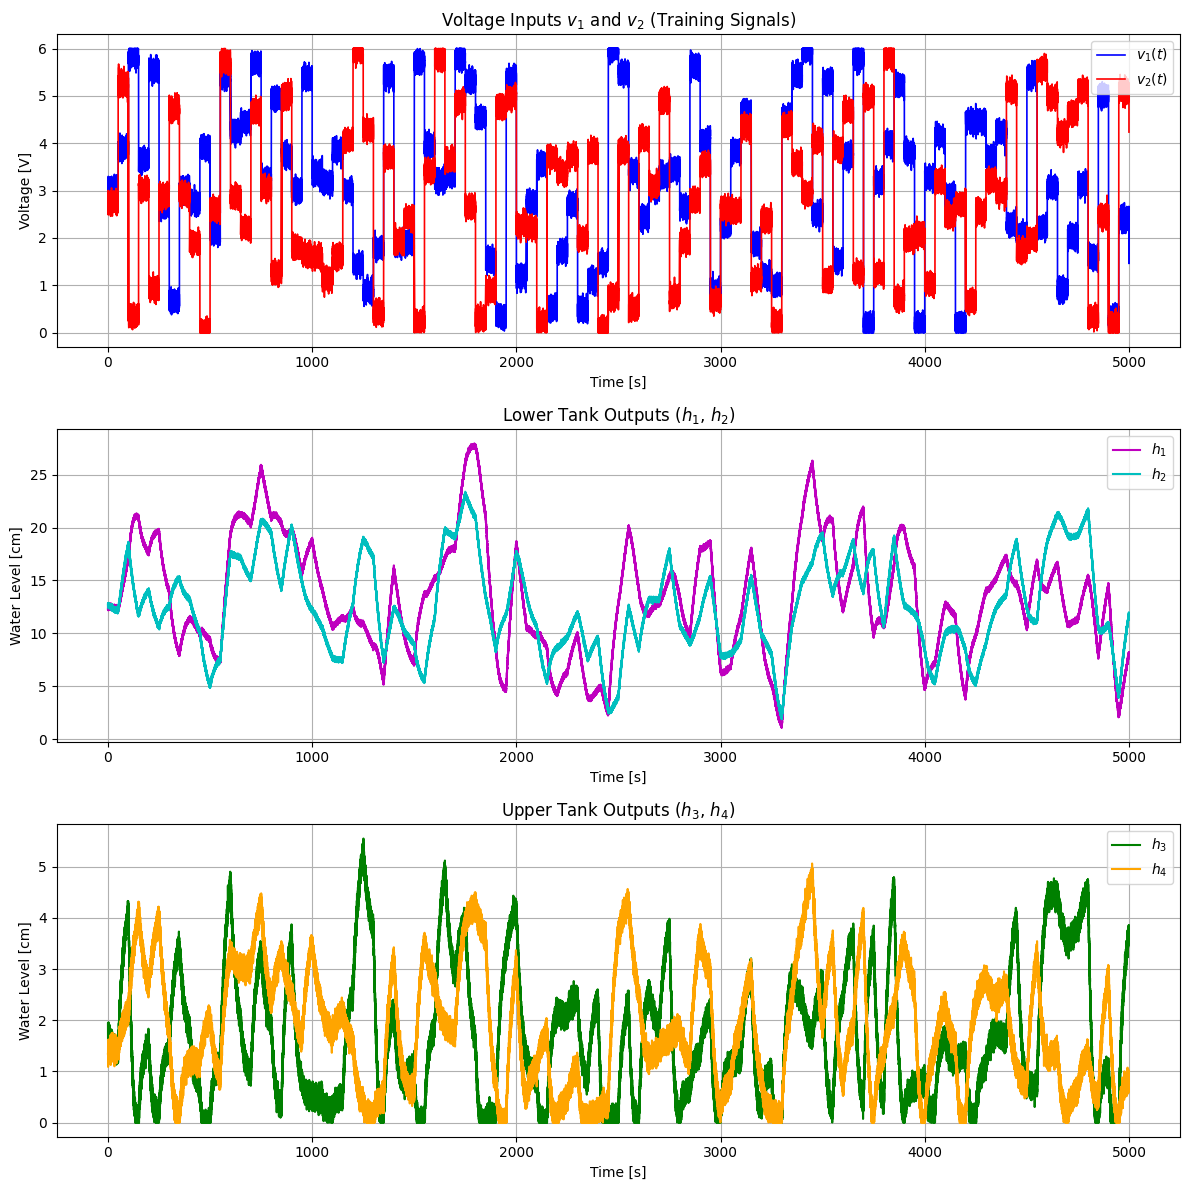

In [56]:
# Figure for visualizing the input and output signals of the system
plt.figure(figsize=(12, 12))

# Subplot 1: Control input signals (Pump voltages v1 and v2)
plt.subplot(3, 1, 1)
plt.plot(t_full, u_full[:, 0], 'b', linewidth=1.2, label='$v_1(t)$')
plt.plot(t_full, u_full[:, 1], 'r', linewidth=1.2, label='$v_2(t)$')
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')
plt.title('Voltage Inputs $v_1$ and $v_2$ (Training Signals)')
plt.legend(loc='upper right')
plt.grid(True)

# Subplot 2: Lower tank levels (h1 and h2)
plt.subplot(3, 1, 2)
plt.plot(t_full, h1_full, 'm', linewidth=1.5, label='$h_1$')
plt.plot(t_full, h2_full, 'c', linewidth=1.5, label='$h_2$')
plt.xlabel('Time [s]')
plt.ylabel('Water Level [cm]')
plt.title('Lower Tank Outputs ($h_1$, $h_2$)')
plt.legend(loc='upper right')
plt.grid(True)

# Subplot 3: Upper tank levels (h3 and h4)
plt.subplot(3, 1, 3)
plt.plot(t_full, h3_full, 'g', linewidth=1.5, label='$h_3$')
plt.plot(t_full, h4_full, 'orange', linewidth=1.5, label='$h_4$')
plt.xlabel('Time [s]')
plt.ylabel('Water Level [cm]')
plt.title('Upper Tank Outputs ($h_3$, $h_4$)')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [57]:
def kalman_filter(z, Q=1e-5, R=1e-2):
    n = len(z)
    x_hat = np.zeros(n)      # Level estimation
    P = np.zeros(n)          # Error covariance
    x_hat[0] = z[0]
    P[0] = 1.0

    for k in range(1, n):
        # Prediction
        x_hat_minus = x_hat[k-1]
        P_minus = P[k-1] + Q

        # Update
        K = P_minus / (P_minus + R)
        x_hat[k] = x_hat_minus + K * (z[k] - x_hat_minus)
        P[k] = (1 - K) * P_minus
        
    return x_hat

# Application with tuning parameters (Q: process, R: sensor)
h1_full = kalman_filter(h1_full)
h2_full = kalman_filter(h2_full)
h3_full = kalman_filter(h3_full)
h4_full = kalman_filter(h4_full)
u_full[:,0] = kalman_filter(u_full[:,0])
u_full[:,1] = kalman_filter(u_full[:,1])

## Preprocesamiento, normalización y división de datos

In [58]:
# Inputs: Using original raw data (non-smoothed) for state and control signals
X_train = np.hstack([
    h1_full[:-1, None],
    h2_full[:-1, None],
    h3_full[:-1, None],
    h4_full[:-1, None],
    u_full[:-1, :]
])

# Outputs: Original next state used for training the transition model
Y_train = np.hstack([
    h1_full[1:, None],
    h2_full[1:, None],
    h3_full[1:, None],
    h4_full[1:, None]
])

## Arquitectura de red neuronal para entrenamiento

In [59]:
# MIMO system dimensions
INPUT_SIZE = 6   # [h1(k), h2(k), h3(k), h4(k), v1(k), v2(k)]
OUTPUT_SIZE = 4  # [h1(k+1), h2(k+1), h3(k+1), h4(k+1)]
HIDDEN_LAYERS = 4
HIDDEN_NEURONS = 48

class PINN_StateSpace_SiLU(nn.Module):
    def __init__(self, input_size, output_size, num_layers, num_neurons):
        super(PINN_StateSpace_SiLU, self).__init__()

        layers = []

        # Input layer: Processes states and controls simultaneously
        layers.append(nn.Linear(input_size, num_neurons))
        layers.append(nn.SiLU())

        # Hidden layers: Capture coupling between the 4 tanks
        for _ in range(num_layers):
            layers.append(nn.Linear(num_neurons, num_neurons))
            layers.append(nn.SiLU())

        # Output layer: Predicts the 4 states at k+1
        layers.append(nn.Linear(num_neurons, output_size))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Determine the computing device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model instance adapted for the 4-tank system
model = PINN_StateSpace_SiLU(INPUT_SIZE, OUTPUT_SIZE, HIDDEN_LAYERS, HIDDEN_NEURONS).to(device)

print(f"MIMO PINN Model (4 Tanks) created. Inputs: {INPUT_SIZE}, Outputs: {OUTPUT_SIZE}")
print(f"Current device: {device}")

MIMO PINN Model (4 Tanks) created. Inputs: 6, Outputs: 4
Current device: cuda


## Funciones de normalización y denormalización

In [60]:
# Min-Max normalization to scale data between 0 and 1
def normalize_data(data, data_min, data_max):
    denom = data_max - data_min
    if denom == 0:
        return data
    return (data - data_min) / denom

# Inverse denormalization to restore data to its original physical units
def denormalize_data(data_norm, data_min, data_max):
    return data_norm * (data_max - data_min) + data_min

## Parámetros de escala para entrenamiento

In [61]:
# Dictionary structure to store the Min/Max limits for each variable
SCALING_PARAMS = {}

# Scaling parameters for control inputs (v1 and v2) from u_full
v1_min, v1_max = X_train[:, 4].min(), X_train[:, 4].max()
v2_min, v2_max = X_train[:, 5].min(), X_train[:, 5].max()

SCALING_PARAMS['v1'] = {'min': v1_min, 'max': v1_max}
SCALING_PARAMS['v2'] = {'min': v2_min, 'max': v2_max}

# Scaling parameters for Tank 1 levels
h1_min = min(X_train[:, 0].min(), Y_train[:, 0].min())
h1_max = max(X_train[:, 0].max(), Y_train[:, 0].max())
SCALING_PARAMS['h1'] = {'min': h1_min, 'max': h1_max}

# Scaling parameters for Tank 2 levels
h2_min = min(X_train[:, 1].min(), Y_train[:, 1].min())
h2_max = max(X_train[:, 1].max(), Y_train[:, 1].max())
SCALING_PARAMS['h2'] = {'min': h2_min, 'max': h2_max}

# Scaling parameters for Tank 3 levels
h3_min = min(X_train[:, 2].min(), Y_train[:, 2].min())
h3_max = max(X_train[:, 2].max(), Y_train[:, 2].max())
SCALING_PARAMS['h3'] = {'min': h3_min, 'max': h3_max}

# Scaling parameters for Tank 4 levels
h4_min = min(X_train[:, 3].min(), Y_train[:, 3].min())
h4_max = max(X_train[:, 3].max(), Y_train[:, 3].max())
SCALING_PARAMS['h4'] = {'min': h4_min, 'max': h4_max}

print("Scaling parameters defined for the MIMO model [h1, h2, h3, h4, v1, v2].")

Scaling parameters defined for the MIMO model [h1, h2, h3, h4, v1, v2].


## Normalización de datos de entrada y salida para entrenamiento

In [62]:
# Decomposition of X_train into current state and control inputs
h1_k = X_train[:, 0]
h2_k = X_train[:, 1]
h3_k = X_train[:, 2]
h4_k = X_train[:, 3]
v1_k = X_train[:, 4]
v2_k = X_train[:, 5]

# Decomposition of Y_train into target next states
h1_next = Y_train[:, 0]
h2_next = Y_train[:, 1]
h3_next = Y_train[:, 2]
h4_next = Y_train[:, 3]

# Min-Max normalization applied to each individual input variable
h1_k_norm = normalize_data(h1_k, SCALING_PARAMS['h1']['min'], SCALING_PARAMS['h1']['max'])
h2_k_norm = normalize_data(h2_k, SCALING_PARAMS['h2']['min'], SCALING_PARAMS['h2']['max'])
h3_k_norm = normalize_data(h3_k, SCALING_PARAMS['h3']['min'], SCALING_PARAMS['h3']['max'])
h4_k_norm = normalize_data(h4_k, SCALING_PARAMS['h4']['min'], SCALING_PARAMS['h4']['max'])
v1_k_norm = normalize_data(v1_k, SCALING_PARAMS['v1']['min'], SCALING_PARAMS['v1']['max'])
v2_k_norm = normalize_data(v2_k, SCALING_PARAMS['v2']['min'], SCALING_PARAMS['v2']['max'])

# Min-Max normalization applied to each individual output variable
h1_next_norm = normalize_data(h1_next, SCALING_PARAMS['h1']['min'], SCALING_PARAMS['h1']['max'])
h2_next_norm = normalize_data(h2_next, SCALING_PARAMS['h2']['min'], SCALING_PARAMS['h2']['max'])
h3_next_norm = normalize_data(h3_next, SCALING_PARAMS['h3']['min'], SCALING_PARAMS['h3']['max'])
h4_next_norm = normalize_data(h4_next, SCALING_PARAMS['h4']['min'], SCALING_PARAMS['h4']['max'])

# Reassembly of normalized datasets for MIMO neural network training
X_train_norm = np.hstack([
    h1_k_norm[:, None],
    h2_k_norm[:, None],
    h3_k_norm[:, None],
    h4_k_norm[:, None],
    v1_k_norm[:, None],
    v2_k_norm[:, None]
])

Y_train_norm = np.hstack([
    h1_next_norm[:, None],
    h2_next_norm[:, None],
    h3_next_norm[:, None],
    h4_next_norm[:, None]
])

print("Normalization successfully applied to the 4-tank MIMO structure.")
print(f"Final dimensions: X_train_norm {X_train_norm.shape}, Y_train_norm {Y_train_norm.shape}")

Normalization successfully applied to the 4-tank MIMO structure.
Final dimensions: X_train_norm (100000, 6), Y_train_norm (100000, 4)


## Tensores de entrenamiento

In [63]:
# Training Tensors for Data Loss
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32).to(device)
Y_train_tensor = torch.tensor(Y_train_norm, dtype=torch.float32).to(device)

# Physics tensor with gradient tracking for ODE residual evaluation
X_physics_tensor = X_train_tensor.clone().detach().requires_grad_(True)

print(f"\nPyTorch tensor conversion completed on device: {device}")
print(f"X_train_tensor.shape (Data Loss - MIMO 6): {X_train_tensor.shape}")
print(f"Y_train_tensor.shape (Data Loss - MIMO 4): {Y_train_tensor.shape}")
print(f"X_physics_tensor.shape (Physics Loss - MIMO 6): {X_physics_tensor.shape}")


PyTorch tensor conversion completed on device: cuda
X_train_tensor.shape (Data Loss - MIMO 6): torch.Size([100000, 6])
Y_train_tensor.shape (Data Loss - MIMO 4): torch.Size([100000, 4])
X_physics_tensor.shape (Physics Loss - MIMO 6): torch.Size([100000, 6])


## Función de pérdida física para la red neuronal informada por físicas

In [64]:
class PhysicsLoss(nn.Module):
    def __init__(self, A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2, epsilon, dt, SCALING_PARAMS):
        # Calculation of residuals for the 4-tank system: transition k -> k+1
        super(PhysicsLoss, self).__init__()

        # Store physical constants as tensors
        self.A1, self.A2 = torch.tensor(A1).to(device), torch.tensor(A2).to(device)
        self.A3, self.A4 = torch.tensor(A3).to(device), torch.tensor(A4).to(device)
        self.a1, self.a2 = torch.tensor(a1).to(device), torch.tensor(a2).to(device)
        self.a3, self.a4 = torch.tensor(a3).to(device), torch.tensor(a4).to(device)
        self.g = torch.tensor(g).to(device)
        self.k1, self.k2 = torch.tensor(k1).to(device), torch.tensor(k2).to(device)
        self.gamma1 = torch.tensor(gamma1).to(device)
        self.gamma2 = torch.tensor(gamma2).to(device)
        self.epsilon = torch.tensor(epsilon, dtype=torch.float32).to(device)
        self.dt = torch.tensor(dt, dtype=torch.float32).to(device)

        # Denormalization parameters for states and pump voltages
        self.h1_min, self.h1_max = torch.tensor(SCALING_PARAMS['h1']['min']).to(device), torch.tensor(SCALING_PARAMS['h1']['max']).to(device)
        self.h2_min, self.h2_max = torch.tensor(SCALING_PARAMS['h2']['min']).to(device), torch.tensor(SCALING_PARAMS['h2']['max']).to(device)
        self.h3_min, self.h3_max = torch.tensor(SCALING_PARAMS['h3']['min']).to(device), torch.tensor(SCALING_PARAMS['h3']['max']).to(device)
        self.h4_min, self.h4_max = torch.tensor(SCALING_PARAMS['h4']['min']).to(device), torch.tensor(SCALING_PARAMS['h4']['max']).to(device)
        self.v1_min, self.v1_max = torch.tensor(SCALING_PARAMS['v1']['min']).to(device), torch.tensor(SCALING_PARAMS['v1']['max']).to(device)
        self.v2_min, self.v2_max = torch.tensor(SCALING_PARAMS['v2']['min']).to(device), torch.tensor(SCALING_PARAMS['v2']['max']).to(device)

    def forward(self, x_norm, h_next_pred_norm):
        # Denormalization of current state k
        h1_k = self.h1_min + x_norm[:, 0:1] * (self.h1_max - self.h1_min)
        h2_k = self.h2_min + x_norm[:, 1:2] * (self.h2_max - self.h2_min)
        h3_k = self.h3_min + x_norm[:, 2:3] * (self.h3_max - self.h3_min)
        h4_k = self.h4_min + x_norm[:, 3:4] * (self.h4_max - self.h4_min)
        v1_k = self.v1_min + x_norm[:, 4:5] * (self.v1_max - self.v1_min)
        v2_k = self.v2_min + x_norm[:, 5:6] * (self.v2_max - self.v2_min)

        # Denormalization of predicted state k+1
        h1_k1_pred = self.h1_min + h_next_pred_norm[:, 0:1] * (self.h1_max - self.h1_min)
        h2_k1_pred = self.h2_min + h_next_pred_norm[:, 1:2] * (self.h2_max - self.h2_min)
        h3_k1_pred = self.h3_min + h_next_pred_norm[:, 2:3] * (self.h3_max - self.h3_min)
        h4_k1_pred = self.h4_min + h_next_pred_norm[:, 3:4] * (self.h4_max - self.h4_min)

        # Torricelli’s Law and Mass Balance derivatives
        h1_s = torch.max(h1_k, self.epsilon)
        h2_s = torch.max(h2_k, self.epsilon)
        h3_s = torch.max(h3_k, self.epsilon)
        h4_s = torch.max(h4_k, self.epsilon)

        dh1_dt = -(self.a1/self.A1)*torch.sqrt(2*self.g*h1_s) + (self.a3/self.A1)*torch.sqrt(2*self.g*h3_s) + (self.gamma1*self.k1/self.A1)*v1_k
        dh2_dt = -(self.a2/self.A2)*torch.sqrt(2*self.g*h2_s) + (self.a4/self.A2)*torch.sqrt(2*self.g*h4_s) + (self.gamma2*self.k2/self.A2)*v2_k
        dh3_dt = -(self.a3/self.A3)*torch.sqrt(2*self.g*h3_s) + ((1-self.gamma2)*self.k2/self.A3)*v2_k
        dh4_dt = -(self.a4/self.A4)*torch.sqrt(2*self.g*h4_s) + ((1-self.gamma1)*self.k1/self.A4)*v1_k

        # Physics residuals based on Euler discretization
        R1 = h1_k1_pred - (h1_k + self.dt * dh1_dt)
        R2 = h2_k1_pred - (h2_k + self.dt * dh2_dt)
        R3 = h3_k1_pred - (h3_k + self.dt * dh3_dt)
        R4 = h4_k1_pred - (h4_k + self.dt * dh4_dt)

        return R1, R2, R3, R4

## Función de cálculo total de la pérdida de la red neuronal

In [65]:
def calculate_total_loss(model, physics_loss_module, X_train, Y_train, X_res, w_data=1.0, w_res=200.0, w_ic=10.0):
    # Data loss (Supervised - Mean Squared Error)
    h_pred_data = model(X_train)
    loss_data = torch.mean((h_pred_data - Y_train) ** 2)

    # Residual loss (Physics / PINN)
    h_pred_res = model(X_res)

    # MIMO system residuals
    R1, R2, R3, R4 = physics_loss_module(X_res, h_pred_res)

    # Sum of squared physical residuals
    loss_res = torch.mean(R1 ** 2) + torch.mean(R2 ** 2) + \
               torch.mean(R3 ** 2) + torch.mean(R4 ** 2)

    # Initial conditions (IC) loss
    X_ic = X_train[0:1]
    h_pred_ic = model(X_ic)
    Y_ic_target = Y_train[0:1]
    loss_ic = torch.mean((h_pred_ic - Y_ic_target) ** 2)

    # Weighted total loss
    total_loss = w_data * loss_data + w_res * loss_res + w_ic * loss_ic

    return total_loss, loss_data, loss_res, loss_ic

## Inicialización de pérdida física e historial de entrenamiento

In [66]:
# Stability parameter to prevent infinite gradients in sqrt(h)
epsilon = 1e-6

# Move the neural network model to the computing device (GPU/CPU)
model.to(device)

# Initialize the physics loss module with MIMO system parameters
physics_loss_module = PhysicsLoss(
    A1, A2, A3, A4,
    a1, a2, a3, a4,
    g, k1, k2,
    gamma1, gamma2,
    epsilon, dt, SCALING_PARAMS
).to(device)

# History lists to monitor training convergence
loss_history = []
loss_data_history = []
loss_res_history = []
loss_ic_history = []

print("Physics loss module configured for the 4-tank system.")

Physics loss module configured for the 4-tank system.


## Primera fase de entrenamiento con optimizador Adam

In [ ]:
# Definition of weights for the loss function
W_DATA = 1.0
W_RES = 100.0
W_IC = 10.0

LEARNING_RATE_ADAM = 1e-3
NUM_EPOCHS_ADAM = 4000
optimizer_adam = optim.Adam(model.parameters(), lr=LEARNING_RATE_ADAM)

print(f"--- PHASE 1: Starting Adam training ({NUM_EPOCHS_ADAM} epochs) ---")
print(f"Training for a system with 4 states and 2 inputs...")

for epoch in range(1, NUM_EPOCHS_ADAM + 1):
    model.train()
    optimizer_adam.zero_grad()

    # Total loss calculation using the 4-tank adapted module
    total_loss, loss_data, loss_res, loss_ic = calculate_total_loss(
        model,
        physics_loss_module,
        X_train_tensor,
        Y_train_tensor,
        X_physics_tensor,
        w_data=W_DATA,
        w_res=W_RES,
        w_ic=W_IC
    )

    # Backpropagation
    total_loss.backward()
    optimizer_adam.step()

    # Progress monitoring and history storage every 250 epochs
    if epoch % 250 == 0:
        loss_history.append(total_loss.item())
        loss_data_history.append(loss_data.item())
        loss_res_history.append(loss_res.item())
        loss_ic_history.append(loss_ic.item())

        # Progress printout: L_D (Data Loss), L_R (Physics Residual Loss)
        print(f"Adam Epoch: {epoch}/{NUM_EPOCHS_ADAM} | Total Loss: {total_loss.item():.6e} | L_D: {loss_data.item():.6e} | L_R: {loss_res.item():.6e}")

print("--- PHASE 1 COMPLETED ---")
print(f"Final Adam loss: {total_loss.item():.6e}")

--- PHASE 1: Starting Adam training (4000 epochs) ---
Training for a system with 4 states and 2 inputs...


Adam Epoch: 250/4000 | Total Loss: 5.355005e+02 | L_D: 2.134966e-02 | L_R: 7.139309e+00
Adam Epoch: 500/4000 | Total Loss: 5.385158e+01 | L_D: 5.079824e-03 | L_R: 7.179195e-01
Adam Epoch: 750/4000 | Total Loss: 4.455845e+01 | L_D: 4.607117e-03 | L_R: 5.940236e-01
Adam Epoch: 1000/4000 | Total Loss: 1.428810e+01 | L_D: 1.106687e-03 | L_R: 1.904773e-01
Adam Epoch: 1250/4000 | Total Loss: 8.630498e+00 | L_D: 5.821439e-04 | L_R: 1.150514e-01
Adam Epoch: 1500/4000 | Total Loss: 5.086101e+00 | L_D: 2.621179e-04 | L_R: 6.779686e-02
Adam Epoch: 1750/4000 | Total Loss: 3.549507e+00 | L_D: 1.676036e-04 | L_R: 4.730918e-02
Adam Epoch: 2000/4000 | Total Loss: 2.821066e+00 | L_D: 1.520812e-04 | L_R: 3.759524e-02
Adam Epoch: 2250/4000 | Total Loss: 2.374545e+00 | L_D: 1.509858e-04 | L_R: 3.164031e-02
Adam Epoch: 2500/4000 | Total Loss: 2.298907e+00 | L_D: 1.554305e-04 | L_R: 3.063091e-02
Adam Epoch: 2750/4000 | Total Loss: 1.876675e+00 | L_D: 1.540146e-04 | L_R: 2.499999e-02
Adam Epoch: 3000/4000 | 

## Segunda fase de entrenamiento con optimizador L-BFGS

In [68]:
# L-BFGS optimizer configuration
optimizer_lbfgs = optim.LBFGS(
    model.parameters(),
    lr=0.5,
    max_iter=4000,
    max_eval=4000,
    history_size=50,
    tolerance_grad=1e-9,
    tolerance_change=1e-11,
    line_search_fn="strong_wolfe" # Line search to guarantee descent
)

lbfgs_eval_count = 0
current_lbfgs_loss = 0.0

def closure():
    global lbfgs_eval_count, current_lbfgs_loss
    lbfgs_eval_count += 1
    optimizer_lbfgs.zero_grad()

    # Loss calculation for the 4-tank MIMO structure
    total_loss, loss_data, loss_res, loss_ic = calculate_total_loss(
        model,
        physics_loss_module,
        X_train_tensor,
        Y_train_tensor,
        X_physics_tensor,
        w_data=W_DATA,
        w_res=W_RES,
        w_ic=W_IC
    )

    # Backpropagation
    total_loss.backward()

    # Current loss monitoring
    current_lbfgs_loss = total_loss.item()

    if lbfgs_eval_count % 100 == 0:
        print(f"L-BFGS Evaluation: {lbfgs_eval_count} | Loss: {total_loss.item():.6e} | Res: {loss_res.item():.6e}")

    return total_loss

print("\n--- PHASE 2: Starting fine-tuning with L-BFGS-B (High Precision) ---")
print("This process searches for the global minimum of the 4 physical residuals...")
optimizer_lbfgs.step(closure)

print("\n--- PHASE 2 COMPLETED ---")
print(f"L-BFGS fine-tuning finished. Consolidated final loss: {current_lbfgs_loss:.6e}")


--- PHASE 2: Starting fine-tuning with L-BFGS-B (High Precision) ---
This process searches for the global minimum of the 4 physical residuals...
L-BFGS Evaluation: 100 | Loss: 1.162878e+00 | Res: 1.548280e-02
L-BFGS Evaluation: 200 | Loss: 1.007441e+00 | Res: 1.341364e-02
L-BFGS Evaluation: 300 | Loss: 9.447459e-01 | Res: 1.257459e-02
L-BFGS Evaluation: 400 | Loss: 7.561504e-01 | Res: 1.006139e-02
L-BFGS Evaluation: 500 | Loss: 4.823666e-01 | Res: 6.414849e-03
L-BFGS Evaluation: 600 | Loss: 3.075376e-01 | Res: 4.088587e-03
L-BFGS Evaluation: 700 | Loss: 2.080985e-01 | Res: 2.767924e-03
L-BFGS Evaluation: 800 | Loss: 1.356638e-01 | Res: 1.802892e-03
L-BFGS Evaluation: 900 | Loss: 1.127806e-01 | Res: 1.498471e-03
L-BFGS Evaluation: 1000 | Loss: 8.921247e-02 | Res: 1.184499e-03
L-BFGS Evaluation: 1100 | Loss: 7.115762e-02 | Res: 9.440838e-04
L-BFGS Evaluation: 1200 | Loss: 5.243873e-02 | Res: 6.951023e-04
L-BFGS Evaluation: 1300 | Loss: 4.293400e-02 | Res: 5.684991e-04
L-BFGS Evaluation:

## Denormalización de predicción y datos reales después de entrenamiento

In [69]:
# Model evaluation
model.eval()

with torch.no_grad():
    # Predict next state vector [h1, h2, h3, h4] from input [h1_k, h2_k, h3_k, h4_k, v1_k, v2_k]
    h_pred_train_norm = model(X_train_tensor).cpu().numpy()

# Denormalization of the 4 model predictions (k+1 outputs)
h1_pred_train = denormalize_data(h_pred_train_norm[:, 0], SCALING_PARAMS['h1']['min'], SCALING_PARAMS['h1']['max'])
h2_pred_train = denormalize_data(h_pred_train_norm[:, 1], SCALING_PARAMS['h2']['min'], SCALING_PARAMS['h2']['max'])
h3_pred_train = denormalize_data(h_pred_train_norm[:, 2], SCALING_PARAMS['h3']['min'], SCALING_PARAMS['h3']['max'])
h4_pred_train = denormalize_data(h_pred_train_norm[:, 3], SCALING_PARAMS['h4']['min'], SCALING_PARAMS['h4']['max'])

# Denormalization of real data (k+1 targets for comparison)
Y_train_real_norm = Y_train_tensor.cpu().numpy()
h1_train_real = denormalize_data(Y_train_real_norm[:, 0], SCALING_PARAMS['h1']['min'], SCALING_PARAMS['h1']['max'])
h2_train_real = denormalize_data(Y_train_real_norm[:, 1], SCALING_PARAMS['h2']['min'], SCALING_PARAMS['h2']['max'])
h3_train_real = denormalize_data(Y_train_real_norm[:, 2], SCALING_PARAMS['h3']['min'], SCALING_PARAMS['h3']['max'])
h4_train_real = denormalize_data(Y_train_real_norm[:, 3], SCALING_PARAMS['h4']['min'], SCALING_PARAMS['h4']['max'])

# Time vector for validation (k+1)
t_plot = t_full[1:]

print("Denormalized predictions for all 4 tanks.")

Denormalized predictions for all 4 tanks.


## Visualización de tanques 1 y 2: Red neuronal informada por físicas vs Simulación

In [70]:
# PINN PERFORMANCE EVALUATION: METRICS PER TANK

def calculate_metrics(real, pred):
    # Root Mean Square Error (RMSE): Magnitude of the mean squared error
    rmse = np.sqrt(np.mean((real - pred)**2))

    # Mean Absolute Error (MAE): Average physical absolute error
    mae = np.mean(np.abs(real - pred))

    # Variance Actually Fraction (VAF): Accuracy in capturing dynamics (%)
    vaf = max(0, (1 - np.var(real - pred) / np.var(real)) * 100)

    return rmse, mae, vaf

# Metrics calculation for each state predicted by the PINN
rmse1, mae1, vaf1 = calculate_metrics(h1_noisy[1:], h1_pred_train)
rmse2, mae2, vaf2 = calculate_metrics(h2_noisy[1:], h2_pred_train)
rmse3, mae3, vaf3 = calculate_metrics(h3_noisy[1:], h3_pred_train)
rmse4, mae4, vaf4 = calculate_metrics(h4_noisy[1:], h4_pred_train)

# NEURAL NETWORK ACCURACY REPORT
print("\n" + "="*60)
print(f"{'TANK':<12} | {'RMSE [cm]':<12} | {'MAE [cm]':<12} | {'VAF [%]':<10}")
print("-" * 60)
print(f"{'Tank 1 (h1)':<12} | {rmse1:9.4f}    | {mae1:9.4f}    | {vaf1:7.2f}%")
print(f"{'Tank 2 (h2)':<12} | {rmse2:9.4f}    | {mae2:9.4f}    | {vaf2:7.2f}%")
print(f"{'Tank 3 (h3)':<12} | {rmse3:9.4f}    | {mae3:9.4f}    | {vaf3:7.2f}%")
print(f"{'Tank 4 (h4)':<12} | {rmse4:9.4f}    | {mae4:9.4f}    | {vaf4:7.2f}%")
print("="*60 + "\n")


TANK         | RMSE [cm]    | MAE [cm]     | VAF [%]   
------------------------------------------------------------
Tank 1 (h1)  |    0.2061    |    0.1637    |   99.85%
Tank 2 (h2)  |    0.1770    |    0.1435    |   99.83%
Tank 3 (h3)  |    0.1230    |    0.0966    |   99.06%
Tank 4 (h4)  |    0.1125    |    0.0895    |   99.03%



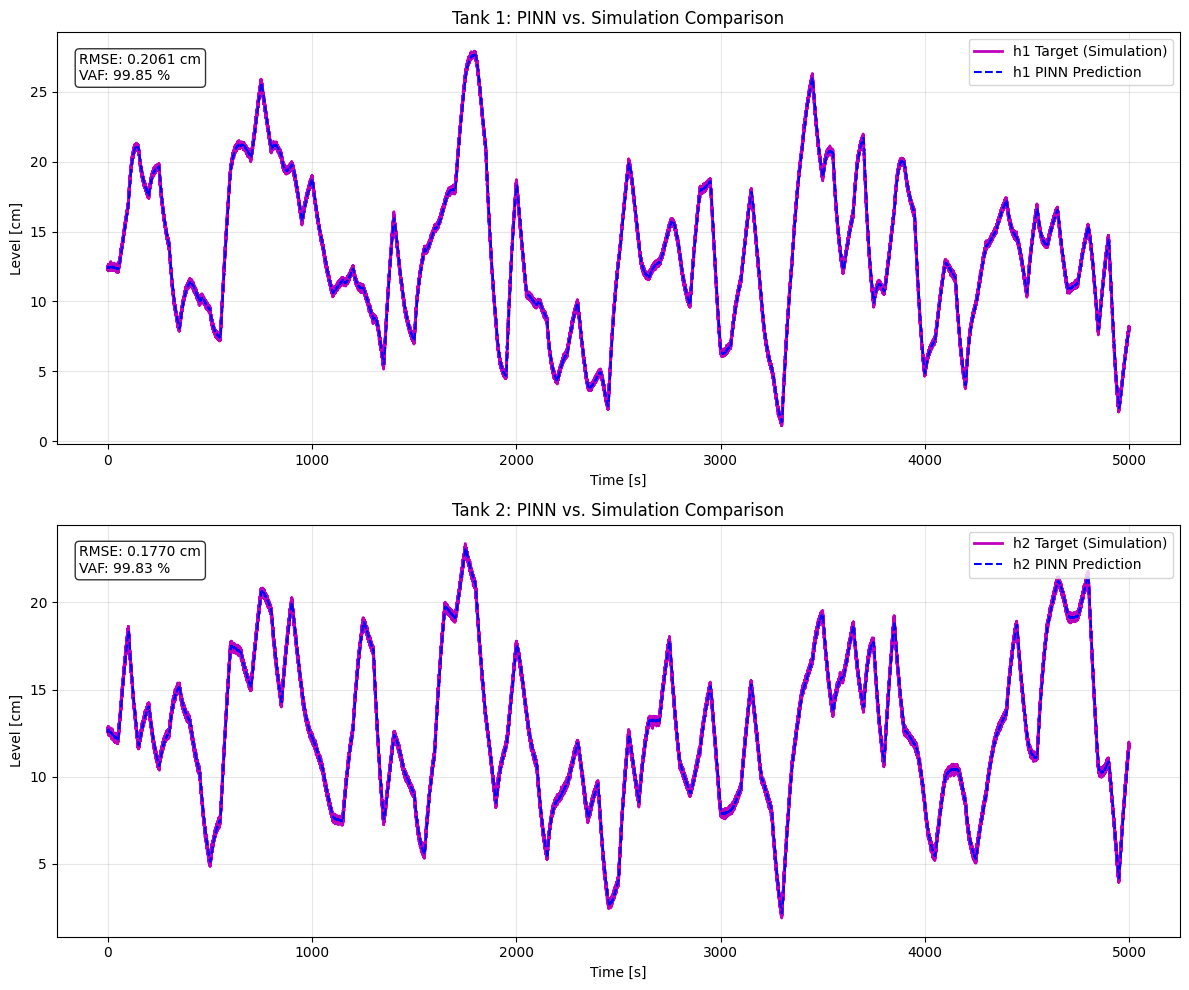

Final Metrics:
Tank 1 -> RMSE: 0.2061, VAF: 99.85%
Tank 2 -> RMSE: 0.1770, VAF: 99.83%


In [71]:
# Visualization Figure
plt.figure(figsize=(12, 10))

# Height h1 (Lower Tank 1)
plt.subplot(2, 1, 1)
plt.plot(t_plot, h1_noisy[1:], 'm', linewidth=2, label='h1 Target (Simulation)')
plt.plot(t_plot, h1_pred_train, 'b--', linewidth=1.5, label='h1 PINN Prediction')
plt.xlabel('Time [s]')
plt.ylabel('Level [cm]')
plt.title('Tank 1: PINN vs. Simulation Comparison')
# Add metrics to the plot
textstr1 = '\n'.join((f'RMSE: {rmse1:.4f} cm', f'VAF: {vaf1:.2f} %'))
plt.gca().text(0.02, 0.95, textstr1, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Height h2 (Lower Tank 2)
plt.subplot(2, 1, 2)
plt.plot(t_plot, h2_noisy[1:], 'm', linewidth=2, label='h2 Target (Simulation)')
plt.plot(t_plot, h2_pred_train, 'b--', linewidth=1.5, label='h2 PINN Prediction')
plt.xlabel('Time [s]')
plt.ylabel('Level [cm]')
plt.title('Tank 2: PINN vs. Simulation Comparison')

# Add metrics to the plot
textstr2 = '\n'.join((f'RMSE: {rmse2:.4f} cm', f'VAF: {vaf2:.2f} %'))
plt.gca().text(0.02, 0.95, textstr2, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Metrics:\nTank 1 -> RMSE: {rmse1:.4f}, VAF: {vaf1:.2f}%")
print(f"Tank 2 -> RMSE: {rmse2:.4f}, VAF: {vaf2:.2f}%")

In [72]:
# Structuring the data for the lower tanks (PINN Results)
data_pinn_inferior_tanks = {
    'Time [s]': t_plot.flatten(),
    'h1_Real [cm]': h1_noisy[1:].flatten(),
    'h1_PINN [cm]': h1_pred_train.flatten(),
    'h2_Real [cm]': h2_noisy[1:].flatten(),
    'h2_PINN [cm]': h2_pred_train.flatten()
}

# DataFrame creation
df_pinn = pd.DataFrame(data_pinn_inferior_tanks)

# Export to CSV
name_pinn_csv = "pinn_lower_tanks_comparison.csv"
df_pinn.to_csv(name_pinn_csv, index=False, sep=',', encoding='utf-8')

print(f"✅ PINN validation file saved as: {name_pinn_csv}")

✅ PINN validation file saved as: pinn_lower_tanks_comparison.csv


## Visualización de tanques 3 y 4: Red neuronal informada por físicas vs Simulación

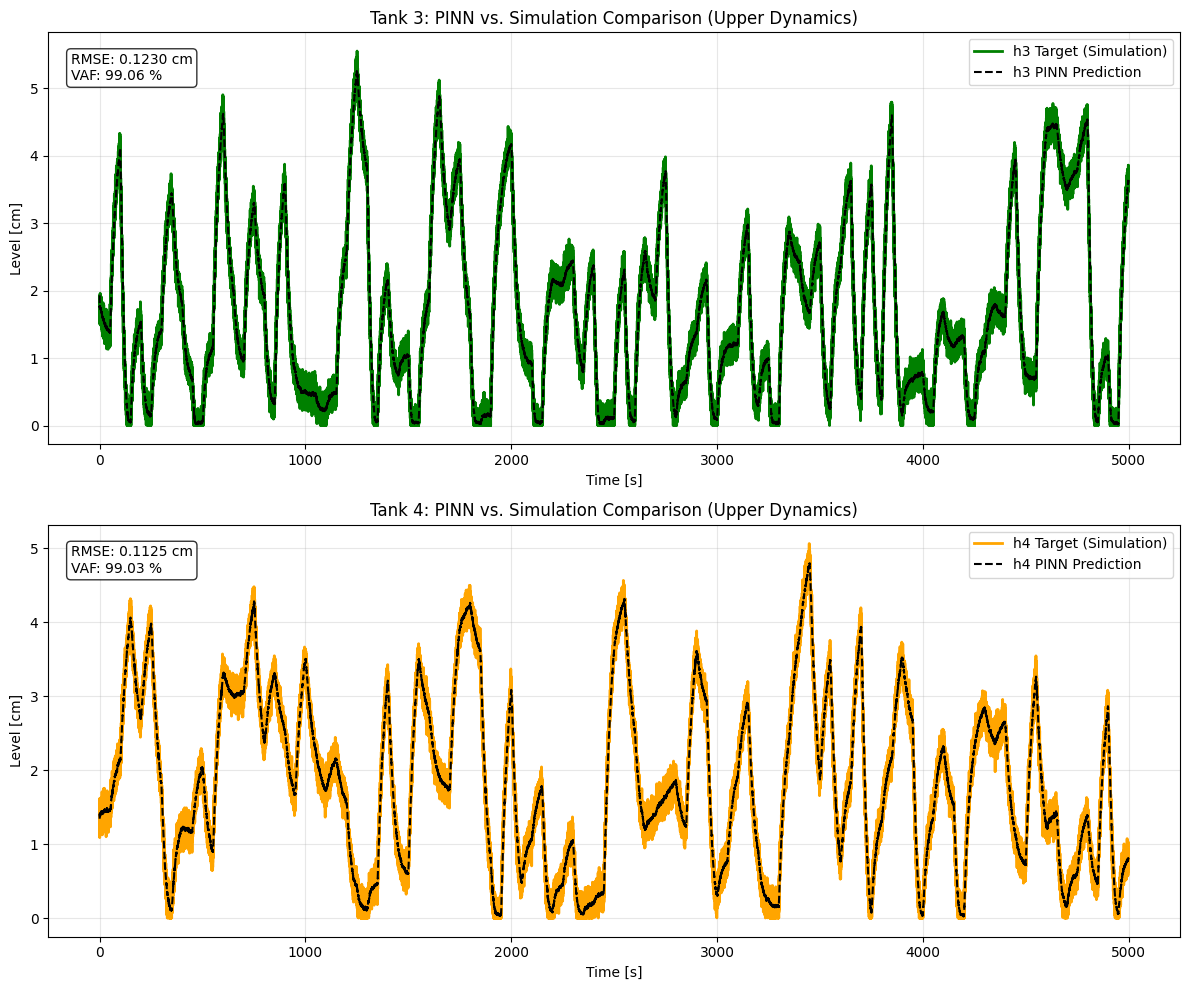

Final Upper Metrics:
Tank 3 -> RMSE: 0.1230, VAF: 99.06%
Tank 4 -> RMSE: 0.1125, VAF: 99.03%


In [73]:
# Visualization Figure for Upper Tanks
plt.figure(figsize=(12, 10))

# Height h3 (Upper Tank 3)
plt.subplot(2, 1, 1)
plt.plot(t_plot, h3_noisy[1:], 'g', linewidth=2, label='h3 Target (Simulation)')
plt.plot(t_plot, h3_pred_train, 'k--', linewidth=1.5, label='h3 PINN Prediction')
plt.xlabel('Time [s]')
plt.ylabel('Level [cm]')
plt.title('Tank 3: PINN vs. Simulation Comparison (Upper Dynamics)')

# Add h3 metrics
textstr3 = '\n'.join((f'RMSE: {rmse3:.4f} cm', f'VAF: {vaf3:.2f} %'))
plt.gca().text(0.02, 0.95, textstr3, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Height h4 (Upper Tank 4)
plt.subplot(2, 1, 2)
plt.plot(t_plot, h4_noisy[1:], 'orange', linewidth=2, label='h4 Target (Simulation)')
plt.plot(t_plot, h4_pred_train, 'k--', linewidth=1.5, label='h4 PINN Prediction')
plt.xlabel('Time [s]')
plt.ylabel('Level [cm]')
plt.title('Tank 4: PINN vs. Simulation Comparison (Upper Dynamics)')

# Add h4 metrics
textstr4 = '\n'.join((f'RMSE: {rmse4:.4f} cm', f'VAF: {vaf4:.2f} %'))
plt.gca().text(0.02, 0.95, textstr4, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Upper Metrics:\nTank 3 -> RMSE: {rmse3:.4f}, VAF: {vaf3:.2f}%")
print(f"Tank 4 -> RMSE: {rmse4:.4f}, VAF: {vaf4:.2f}%")

In [74]:
# Structuring data for the upper tanks (PINN Results)
data_pinn_superior_tanks = {
    'Time [s]': t_plot.flatten(),
    'h3_Real [cm]': h3_train_real.flatten(),
    'h3_PINN [cm]': h3_pred_train.flatten(),
    'h4_Real [cm]': h4_train_real.flatten(),
    'h4_PINN [cm]': h4_pred_train.flatten()
}

# DataFrame creation
df_pinn_sup = pd.DataFrame(data_pinn_superior_tanks)

# Export to CSV
name_pinn_csv_sup = "pinn_upper_tanks_comparison.csv"
df_pinn_sup.to_csv(name_pinn_csv_sup, index=False, sep=',', encoding='utf-8')

print(f"✅ Upper tank data successfully saved to: {name_pinn_csv_sup}")

✅ Upper tank data successfully saved to: pinn_upper_tanks_comparison.csv


## Visualización de pérdidas después de entrenamiento

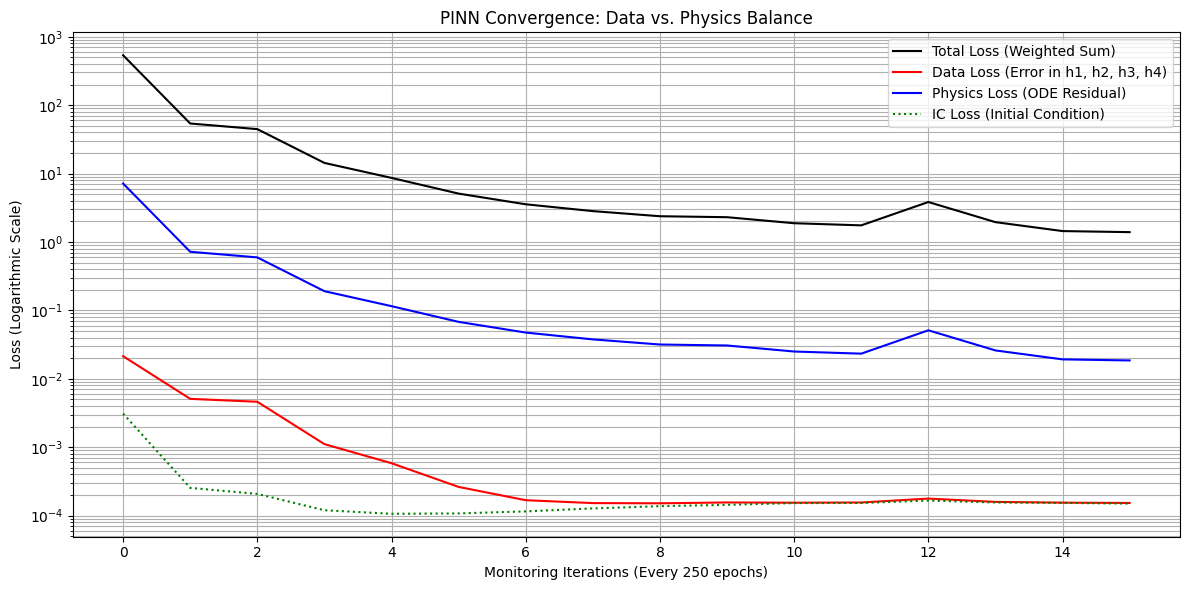

In [75]:
# Loss visualization figure
plt.figure(figsize=(12, 6))

plt.semilogy(loss_history, 'k', label='Total Loss (Weighted Sum)')
plt.semilogy(loss_data_history, 'r', label='Data Loss (Error in h1, h2, h3, h4)')
plt.semilogy(loss_res_history, 'b', label='Physics Loss (ODE Residual)')
plt.semilogy(loss_ic_history, 'g', linestyle=':', label='IC Loss (Initial Condition)')

plt.xlabel('Monitoring Iterations (Every 250 epochs)')
plt.ylabel('Loss (Logarithmic Scale)')
plt.title('PINN Convergence: Data vs. Physics Balance')
plt.legend()
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

## Gráficas de error de los 4 tanques

In [76]:
# Error vector calculation for all 4 tanks (values in cm)
error_h1_pinn = h1_noisy[1:] - h1_pred_train
error_h2_pinn = h2_noisy[1:] - h2_pred_train
error_h3_pinn = h3_noisy[1:] - h3_pred_train
error_h4_pinn = h4_noisy[1:] - h4_pred_train

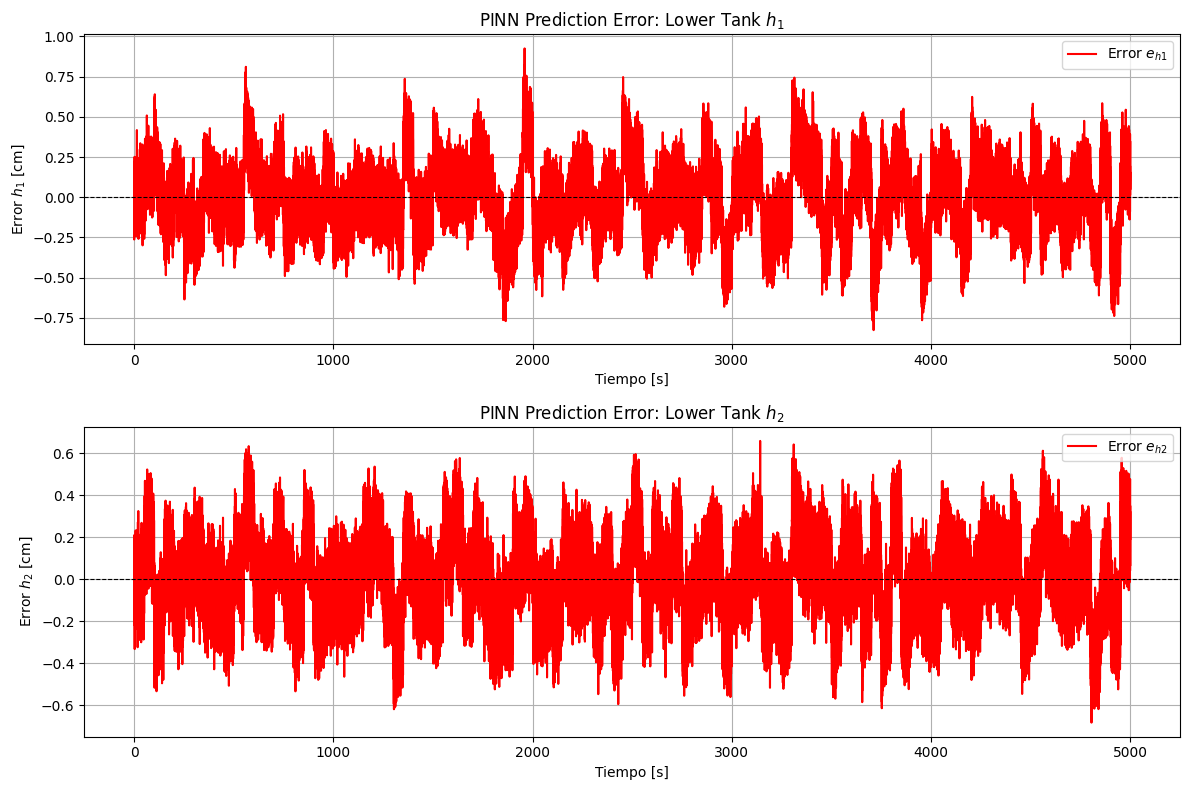

In [77]:
# Error visualization for lower tanks
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t_plot, error_h1_pinn, 'r', linewidth=1.5, label='Error $e_{h1}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Tiempo [s]')
plt.ylabel('Error $h_1$ [cm]')
plt.title('PINN Prediction Error: Lower Tank $h_1$')
plt.legend(loc='upper right')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t_plot, error_h2_pinn, 'r', linewidth=1.5, label='Error $e_{h2}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Tiempo [s]')
plt.ylabel('Error $h_2$ [cm]')
plt.title('PINN Prediction Error: Lower Tank $h_2$')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

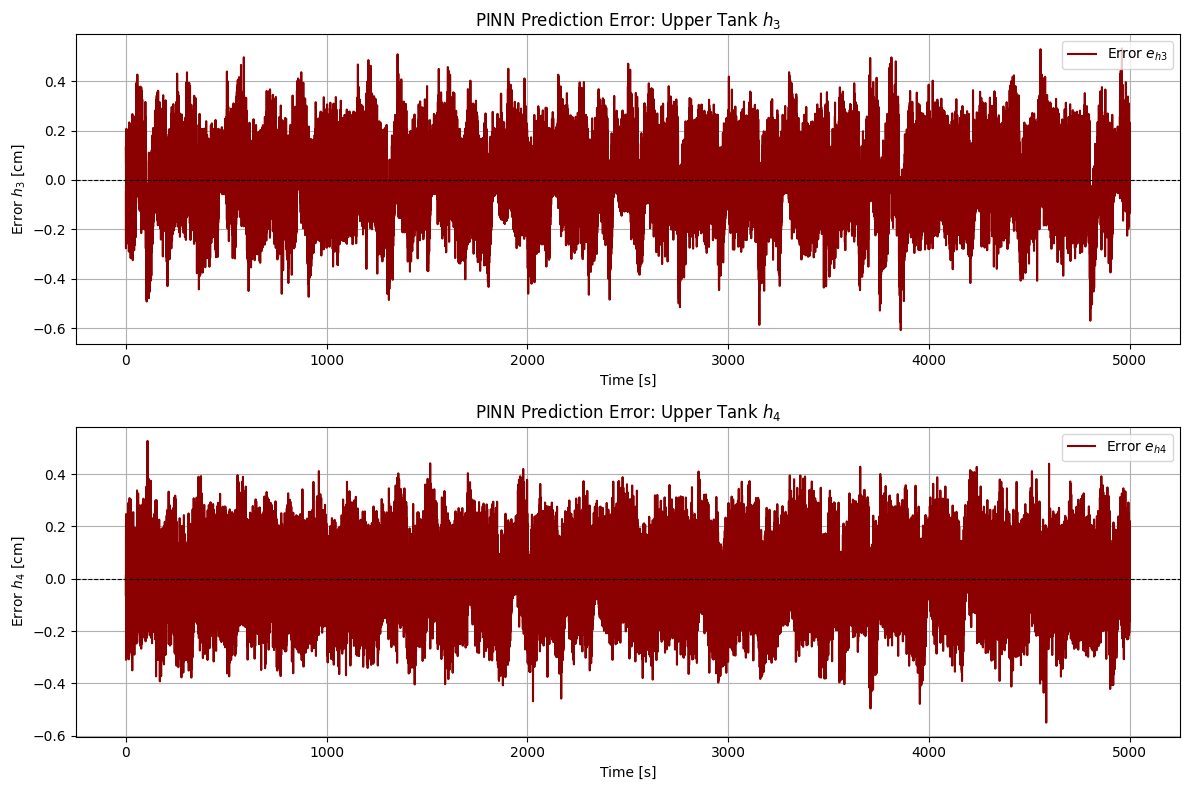

In [78]:
# Error visualization for upper tanks
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(t_plot, error_h3_pinn, 'darkred', linewidth=1.5, label='Error $e_{h3}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Time [s]')
plt.ylabel('Error $h_3$ [cm]')
plt.title('PINN Prediction Error: Upper Tank $h_3$')
plt.legend(loc='upper right')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t_plot, error_h4_pinn, 'darkred', linewidth=1.5, label='Error $e_{h4}$')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.xlabel('Time [s]')
plt.ylabel('Error $h_4$ [cm]')
plt.title('PINN Prediction Error: Upper Tank $h_4$')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

## Métricas de entrenamiento de la red neuronal informada por físicas

In [79]:
# Concatenation of all errors (k+1)
error_full = np.concatenate((error_h1_pinn, error_h2_pinn, error_h3_pinn, error_h4_pinn))

MSE = np.mean(error_full**2)
RMSE = np.sqrt(MSE)
MAE = np.mean(np.abs(error_full))
SSE = np.sum(error_full**2)

# Normalized Root Mean Square Error (NRMSE)
h_real_concat = np.concatenate((h1_train_real, h2_train_real, h3_train_real, h4_train_real))
range_h = np.max(h_real_concat) - np.min(h_real_concat)

if range_h != 0:
    NRMSE = RMSE / range_h
else:
    NRMSE = 0.0

print("\n--------------------------- Approximation Error Metrics -------------------------------")
print(f"MSE (Global Mean Squared Error)\t\t: {MSE:.8e} m^2 \t|({MSE*10000:.8e} cm^2)")
print(f"RMSE (Global Root Mean Squared Error)\t: {RMSE:.8e} m \t|({RMSE*100:.8e} cm)")
print(f"MAE (Global Mean Absolute Error)\t: {MAE:.8e} m \t|({MAE*100:.8e} cm)")
print(f"SSE (Global Sum of Squared Errors)\t: {SSE:.8e} m^2 \t|({SSE*10000:.8e} cm^2)")
print(f"NRMSE (Global Normalized Error)\t\t: {NRMSE:.8e} \t|(Adimensional)")


--------------------------- Approximation Error Metrics -------------------------------
MSE (Global Mean Squared Error)		: 2.53956515e-02 m^2 	|(2.53956515e+02 cm^2)
RMSE (Global Root Mean Squared Error)	: 1.59360132e-01 m 	|(1.59360132e+01 cm)
MAE (Global Mean Absolute Error)	: 1.23314914e-01 m 	|(1.23314914e+01 cm)
SSE (Global Sum of Squared Errors)	: 1.01582606e+04 m^2 	|(1.01582606e+08 cm^2)
NRMSE (Global Normalized Error)		: 5.76078132e-03 	|(Adimensional)


## Histograma de error de predicción

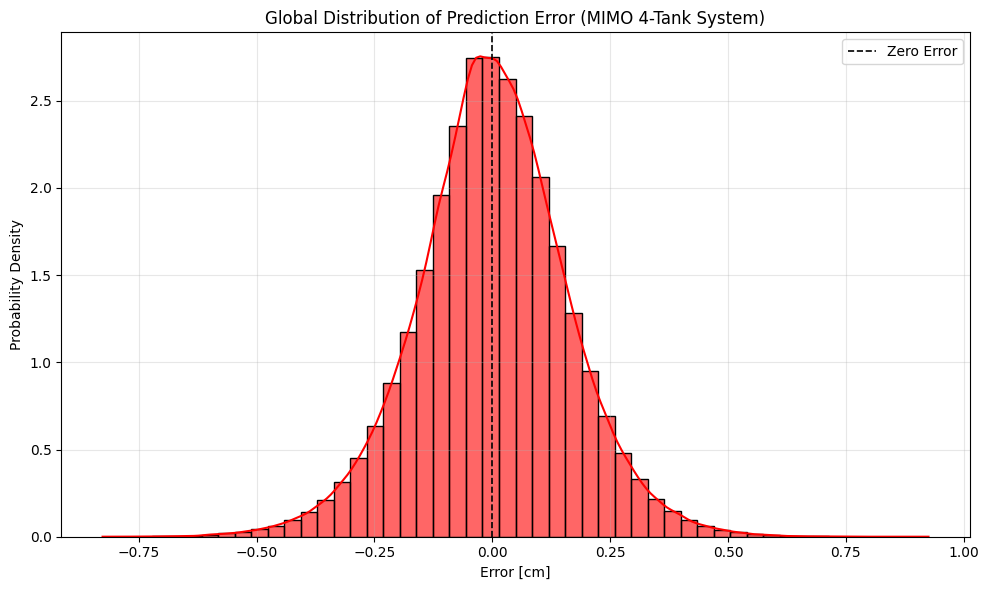

Error Standard Deviation: 0.159360 cm
Mean Error (Bias): -0.000322 cm


In [80]:
plt.figure(figsize=(10, 6))

# Global error distribution (cm)
sns.histplot(error_full, kde=True, color='red', bins=50, stat="density", alpha=0.6)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2, label='Zero Error')
plt.title('Global Distribution of Prediction Error (MIMO 4-Tank System)')
plt.xlabel('Error [cm]')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print(f"Error Standard Deviation: {np.std(error_full):.6f} cm")
print(f"Mean Error (Bias): {np.mean(error_full):.6f} cm")

## Predicción de horizonte de valores futuros de las alturas de los tanques

In [81]:
# Horizon configuration and weight matrices
N_horizon = 25
Nc = 1
dt = 0.2
Q = np.diag([500.0, 500.0, 0.0, 0.0])
R = np.diag([0.01, 0.01])
Rd = np.diag([1.0, 1.0])

# System dimensions
nx = 4
nu = 2
N = N_horizon

# Symbolic variable definition
U = ca.MX.sym('U', nu, Nc)
h0_sym = ca.MX.sym('h0', nx)
h_refs_sym = ca.MX.sym('h_refs', 4, N)
u_prev_sym = ca.MX.sym('u_prev', nu)

# Parameter vector for the solver
P = ca.vertcat(h0_sym, ca.reshape(h_refs_sym, -1, 1), u_prev_sym)

# Optimization variables initialization
cost = 0
g_slew = []

# Extraction of weights and biases from PyTorch to CasADi
params_ca = {}
with torch.no_grad():
    linears = [m for m in model.net if isinstance(m, nn.Linear)]
    for i, layer in enumerate(linears):
        params_ca[f'W{i}'] = ca.DM(layer.weight.cpu().numpy())
        params_ca[f'b{i}'] = ca.DM(layer.bias.cpu().numpy())

# Conversion of cost matrices to CasADi format
Q_ca = ca.DM(Q)
R_ca = ca.DM(R)
Rd_ca = ca.DM(Rd)

# Definition of normalization constants for the PINN
h_min_ca = ca.vertcat(SCALING_PARAMS['h1']['min'], SCALING_PARAMS['h2']['min'],
                      SCALING_PARAMS['h3']['min'], SCALING_PARAMS['h4']['min'])
h_max_ca = ca.vertcat(SCALING_PARAMS['h1']['max'], SCALING_PARAMS['h2']['max'],
                      SCALING_PARAMS['h3']['max'], SCALING_PARAMS['h4']['max'])
v_min_ca = ca.vertcat(SCALING_PARAMS['v1']['min'], SCALING_PARAMS['v2']['min'])
v_max_ca = ca.vertcat(SCALING_PARAMS['v1']['max'], SCALING_PARAMS['v2']['max'])

In [82]:
# --- SYMBOLIC DEFINITION OF THE NETWORK (PINN) IN CASADI ---

# Normalized symbolic input [h1..h4, v1, v2]
x_in_sym = ca.MX.sym('x_in', 6)
x_layer = x_in_sym
num_total_layers = len([k for k in params_ca.keys() if 'W' in k])

# Reconstruction of the network architecture with SiLU activation
for j in range(num_total_layers):
    lin_out = params_ca[f'W{j}'] @ x_layer + params_ca[f'b{j}']
    if j < (num_total_layers - 1):
        # SiLU implementation: x * sigmoid(x)
        x_layer = lin_out / (1 + ca.exp(-lin_out))
    else:
        # Linear output for the last layer
        x_layer = lin_out

# Creation of the CasADi function for the forward pass
PINN_func = ca.Function('PINN_func', [x_in_sym], [x_layer])

# --- CONSTRUCTION OF THE PREDICTION HORIZON AND COST ---

h_loop = h0_sym

for i in range(N):
    if i < Nc:
        u_k = U[:, i]  # Free decision variable
    else:
        u_k = U[:, Nc-1]  # Hold the last control value constant

    h_ref_k = h_refs_sym[:, i]

    # Input variable normalization
    h_norm = (h_loop - h_min_ca) / (h_max_ca - h_min_ca)
    u_norm = (u_k - v_min_ca) / (v_max_ca - v_min_ca)

    # Prediction of the next normalized state
    h_next_norm = PINN_func(ca.vertcat(h_norm, u_norm))

    # Denormalization of the predicted state
    h_next = h_next_norm * (h_max_ca - h_min_ca) + h_min_ca

    # Trajectory update and error calculation
    h_loop = h_next
    err = h_loop - h_ref_k

    # Accumulation of state and control costs
    cost += ca.mtimes([err.T, Q_ca, err])
    cost += ca.mtimes([u_k.T, R_ca, u_k])

    if i < Nc:
        u_prev_step = u_prev_sym if i == 0 else U[:, i-1]
        u_diff = u_k - u_prev_step
        # Slew rate cost (control effort smoothness)
        cost += ca.mtimes([u_diff.T, Rd_ca, u_diff])
        g_slew.append(u_diff)

In [83]:
# --- OPTIMIZATION PROBLEM CONFIGURATION (NLP) ---

# Concatenation of constraints and decision vector
g_total = ca.vertcat(*g_slew)
u_optim = ca.reshape(U, -1, 1)

# NLP problem structure
nlp = {'x': u_optim, 'f': cost, 'g': g_total, 'p': P}

# SQP solver options for real-time execution
opts = {
    'qpsol': 'qpoases',
    'max_iter': 1,
    'qpsol_options': {'printLevel': 'none'},
    'print_iteration': False,
    'print_header': False,
    'print_status': False,
    'print_time': False,
    'error_on_fail': False
}

# Solver instantiation
solver = ca.nlpsol('solver', 'sqpmethod', nlp, opts)

# --- DEFINITION OF BOUNDS AND CONSTRAINTS ---

# Voltage limits for the pumps (Decision variables)
lbx = np.tile([V_min, V_min], Nc)
ubx = np.tile([V_max, V_max], Nc)

# Limits for the maximum voltage change (Slew Rate)
max_delta_v = 0.5
lbg = np.tile([-max_delta_v, -max_delta_v], Nc)
ubg = np.tile([max_delta_v, max_delta_v], Nc)

print(f"NMPC-PINN Solver configured. Dim x: {u_optim.shape}, Dim g: {g_total.shape}")


qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
See the GNU Lesser General Public License for more details.


qpOASES -- An Implementation of the Online Active Set Strategy.
Copyright (C) 2007-2015 by Hans Joachim Ferreau, Andreas Potschka,
Christian Kirches et al. All rights reserved.

qpOASES is distributed under the terms of the 
GNU Lesser General Public License 2.1 in the hope that it will be 
useful, but WITHOUT ANY WARRANTY; without even the implied warranty 
of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. 
See the GNU Lesser General Public License for more details.

NMPC-PINN Solver configured. Dim x: (2, 

In [84]:
# --- TRAJECTORY GENERATORS ---

# Constant value reference
def constant_ref(t, value=12.0):
    return value

# Sinusoidal oscillation reference
def sinusoidal_ref(t, offset=12.0, amp=3.0, freq=0.01):
    return offset + amp * np.sin(2 * np.pi * freq * t)

# Square wave signal reference
def square_ref(t, offset=9.0, amp=2.0, freq=0.005):
    return offset + amp * np.sign(np.sin(2 * np.pi * freq * t))

# Charge/discharge dynamics reference (RC Filter)
def rc_filter_ref(t, tau=10.0, t_change=50.0, v1=10.0, v2=14.0):
    cycle = int(t / t_change)
    target = v2 if cycle % 2 != 0 else v1
    t_relative = t % t_change
    initial_v = v2 if target == v1 else v1
    return target + (initial_v - target) * np.exp(-t_relative / tau)

# Step sequence reference generator
def step_sequence_ref(t, values, period=200):
    index = int(t / period) % len(values)
    return values[index]

# --- REFERENCE SELECTION FOR CONTROL ---

# Signal definition for the lower tanks
h1_reference = lambda t: step_sequence_ref(t, [12, 15, 10, 14, 16])
h2_reference = lambda t: step_sequence_ref(t, [16, 14, 10, 15, 12])
#h1_reference = lambda t: sinusoidal_ref(t)
#h2_reference = lambda t: sinusoidal_ref(t)

In [85]:
# --- TIME AND SIMULATION PARAMETERS ---
T_control = 1500
steps_control = int(T_control / dt)
t_test = np.linspace(0, T_control, steps_control)

# Reference matrix initialization (4 states)
h_ref_full = np.zeros((steps_control, 4))

# Noise configuration for robustness (Sensors and Actuators)
std_sensor = 0.10
std_actuator = 0.15

# Reference profile generation for h1 and h2
for i in range(steps_control):
    t_current = t_test[i]
    h_ref_full[i, 0] = h1_reference(t_current)
    h_ref_full[i, 1] = h2_reference(t_current)

In [86]:
# --- CLOSED-LOOP CONTROL LOOP (NMPC-PINN) ---

# Historical data and initial state initialization
h_history = np.zeros((steps_control, 4))
u_history = np.zeros((steps_control, 2))
h_current = h0.copy()
u_prev_applied = np.array([3.0, 3.0])

# Solver iteration time storage
solve_times = []      
start_wall_time = time.time()

print("Starting PINN-based NMPC...")
print("-" * 80)
print(f"{'Step':<6} | {'h1 (Ref)':<15} | {'h2 (Ref)':<15} | {'V1':<8} | {'V2':<8}")

for k in range(steps_control):
    # Sensor reading with Gaussian noise
    h_measured = np.maximum(h_current + std_sensor * np.random.randn(4), 0.0)

    # Future reference horizon definition
    if k + N < steps_control:
        h_ref_horizon = h_ref_full[k : k + N].T
    else:
        pad = N - (steps_control - k)
        h_ref_horizon = np.hstack([h_ref_full[k:].T, np.tile(h_ref_full[-1:], (pad, 1)).T])

    # Parameter vector construction (Current State, References, Previous Control)
    p_val = ca.vertcat(
        h_measured,
        h_ref_horizon.flatten(order='F'),
        u_prev_applied
    )

    # NMPC solver execution with Warm Start
    u_init = np.tile(u_prev_applied, Nc)
    t_start_iter = time.time()

    sol = solver(x0=u_init, p=p_val,
                 lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg)
    
    t_end_iter = time.time()
    solve_times.append(t_end_iter - t_start_iter)
    u_init = sol['x']

    # Extraction of the immediate optimal control action
    u_all_opt = np.array(sol['x']).reshape(Nc, 2)
    u_nmpc = u_all_opt[0, :]

    # Application of noisy control to the real plant
    u_real = np.clip(u_nmpc + std_actuator * np.random.randn(2), V_min, V_max)

    # Integration of real system dynamics (ODE Plant)
    sol_ode = solve_ivp(
        lambda t, y: nonlinear_ode_system_model(t, y, lambda _: u_real,
                     A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2),
        [0, dt], h_current, t_eval=[dt]
    )

    # State update for the next iteration
    h_current = sol_ode.y[:, -1]
    u_prev_applied = u_nmpc

    # Result storage
    h_history[k] = h_current
    u_history[k] = u_nmpc

    # Telemetry print every 100 steps
    if k % 100 == 0:
        print(f"{k:<6d} | {h_current[0]:5.2f} ({h_ref_full[k,0]:5.2f}) | "
              f"{h_current[1]:5.2f} ({h_ref_full[k,1]:5.2f}) | "
              f"{u_nmpc[0]:5.2f}V | {u_nmpc[1]:5.2f}V")

print("-" * 80)
print("NMPC-PINN Simulation completed.")

# --- Final metrics calculation ---
total_execution_time = time.time() - start_wall_time
total_simulated_time = steps_control * dt
rtf = total_simulated_time / total_execution_time

Starting PINN-based NMPC...
--------------------------------------------------------------------------------
Step   | h1 (Ref)        | h2 (Ref)        | V1       | V2      
0      | 12.39 (12.00) | 12.71 (16.00) |  2.50V |  3.50V
100    | 11.37 (12.00) | 15.64 (16.00) |  3.48V |  6.00V
200    | 12.00 (12.00) | 16.09 (16.00) |  1.80V |  5.04V
300    | 12.94 (12.00) | 16.69 (16.00) |  6.00V |  6.00V
400    | 11.82 (12.00) | 15.40 (16.00) |  2.51V |  1.50V
500    | 11.46 (12.00) | 15.44 (16.00) |  3.34V |  0.00V
600    | 12.01 (12.00) | 15.98 (16.00) |  2.40V |  3.56V
700    | 11.99 (12.00) | 15.99 (16.00) |  1.29V |  2.52V
800    | 11.94 (12.00) | 16.00 (16.00) |  2.31V |  3.99V
900    | 12.06 (12.00) | 15.99 (16.00) |  2.39V |  3.45V
1000   | 13.37 (15.00) | 15.22 (14.00) |  6.00V |  0.00V
1100   | 15.01 (15.00) | 13.86 (14.00) |  5.42V |  2.27V
1200   | 15.06 (15.00) | 13.91 (14.00) |  5.09V |  2.81V
1300   | 16.13 (15.00) | 14.91 (14.00) |  6.00V |  6.00V
1400   | 14.76 (15.00) | 13.

In [87]:
print("\n" + "="*40)
print("       PERFORMANCE METRICS")
print("="*40)

# 1. Total execution time (Wall-clock time)
print(f"Total computing time:       {total_execution_time:.4f} s")

# 2. Average time per solver iteration
avg_solve_time = np.mean(solve_times)
print(f"Average per iteration:      {avg_solve_time*1000:.2f} ms")

# 3. Total physical simulation time
print(f"Simulated time (physical):  {total_simulated_time:.2f} s")

# 4. Real-Time Factor (RTF)
print(f"Real-Time Factor (RTF):     {rtf:.2f}x")

if rtf > 1:
    print(f"\nStatus: The controller is {rtf:.1f} times faster than the real process.")
else:
    print(f"\nStatus: ALERT - The controller is slower than the real process.")

print("="*40)


       PERFORMANCE METRICS
Total computing time:       143.6843 s
Average per iteration:      18.05 ms
Simulated time (physical):  1500.00 s
Real-Time Factor (RTF):     10.44x

Status: The controller is 10.4 times faster than the real process.


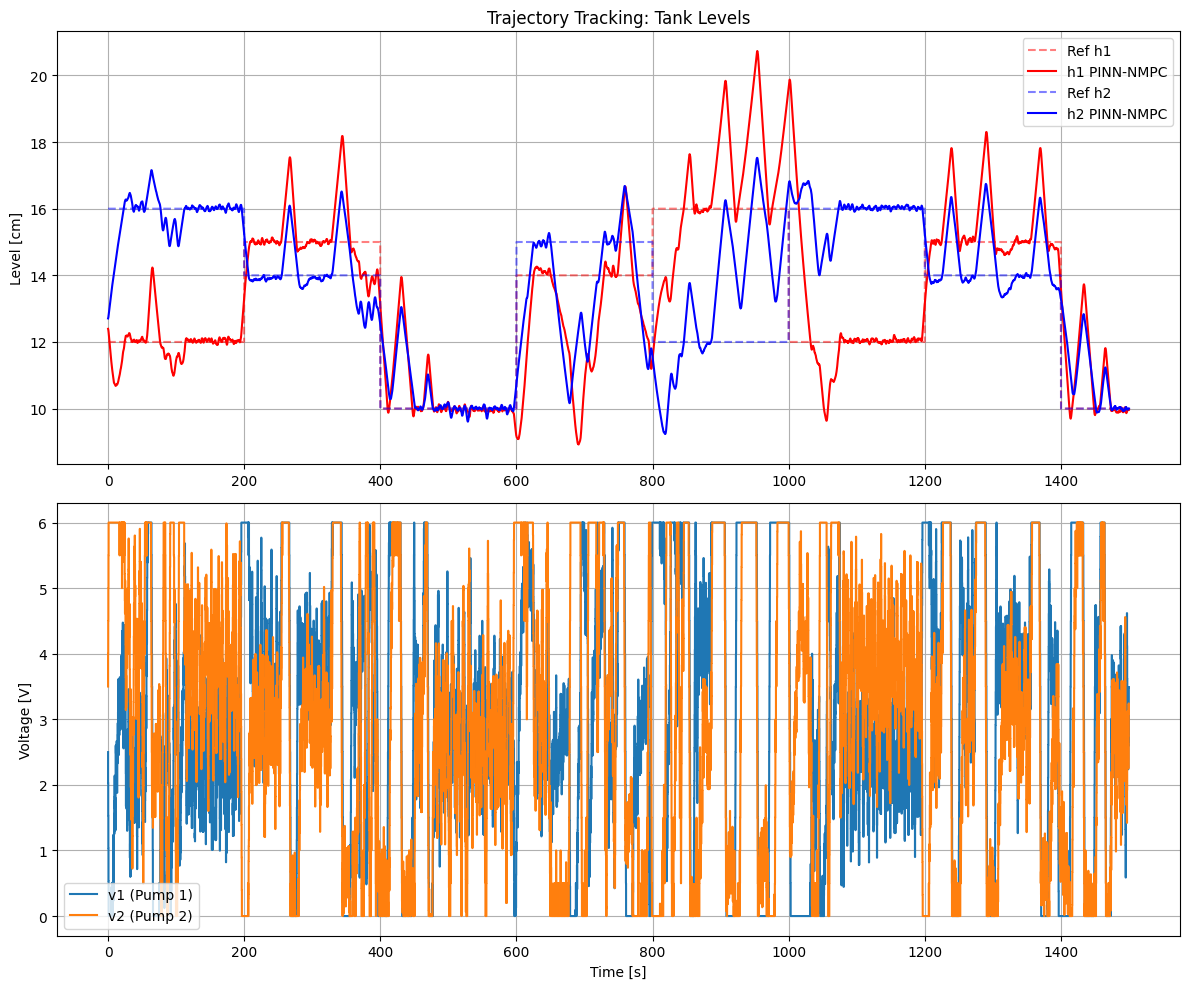

In [88]:
# --- RESULTS VISUALIZATION (TRACKING AND CONTROL) ---

plt.figure(figsize=(12, 10))

# Level Comparison: Reference vs. Real Response
plt.subplot(2, 1, 1)
plt.plot(t_test, h_ref_full[:, 0], 'r--', alpha=0.5, label='Ref h1')
plt.plot(t_test, h_history[:, 0], 'r', label='h1 PINN-NMPC')
plt.plot(t_test, h_ref_full[:, 1], 'b--', alpha=0.5, label='Ref h2')
plt.plot(t_test, h_history[:, 1], 'b', label='h2 PINN-NMPC')
plt.title('Trajectory Tracking: Tank Levels')
plt.ylabel('Level [cm]')
plt.legend()
plt.grid(True)

# Control Effort: Voltage applied to the pumps
plt.subplot(2, 1, 2)
plt.step(t_test[:], u_history[:, 0], label='v1 (Pump 1)')
plt.step(t_test[:], u_history[:, 1], label='v2 (Pump 2)')
plt.ylabel('Voltage [V]')
plt.xlabel('Time [s]')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

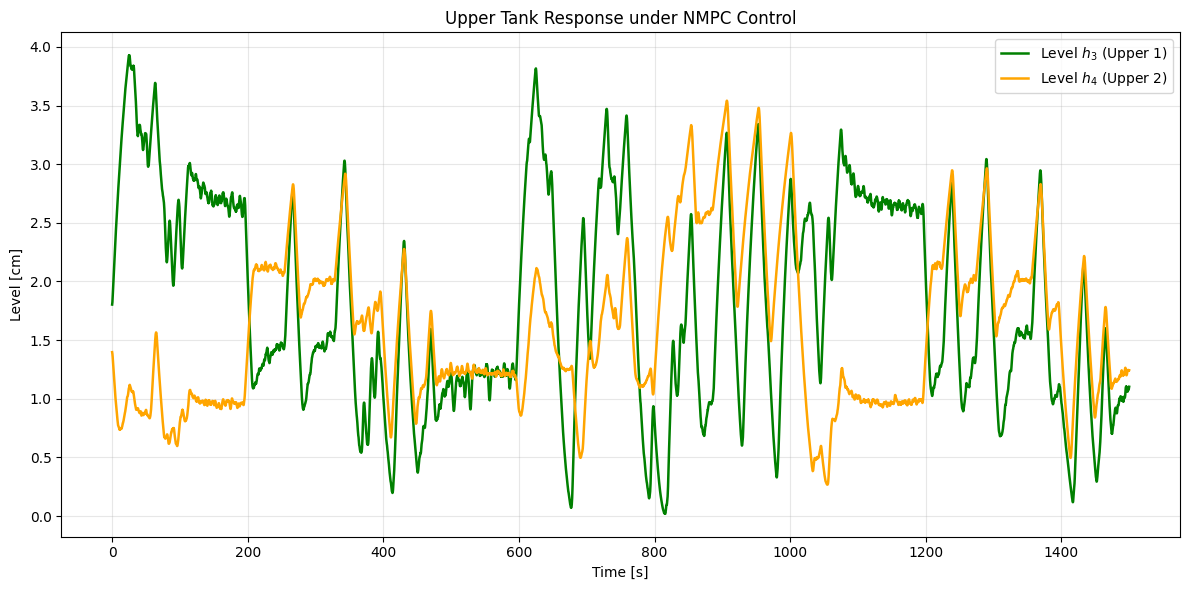

In [89]:
# --- UPPER TANK DYNAMICS VISUALIZATION ---
plt.figure(figsize=(12, 6))

# Trajectory of h3 and h4 (Upper discharge tanks)
plt.plot(t_test, h_history[:, 2], 'g', linewidth=1.8, label='Level $h_3$ (Upper 1)')
plt.plot(t_test, h_history[:, 3], 'orange', linewidth=1.8, label='Level $h_4$ (Upper 2)')

plt.title('Upper Tank Response under NMPC Control')
plt.ylabel('Level [cm]')
plt.xlabel('Time [s]')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [90]:
# --- CONTROL METRICS CALCULATION: PINN-NMPC EVALUATION ---

def calculate_control_metrics(real, ref):
    error = real - ref
    sse = np.sum(error**2)
    rmse = np.sqrt(np.mean(error**2))

    # NRMSE normalized by the dynamic range of the reference
    range_ref = np.max(ref) - np.min(ref)
    nrmse = rmse / range_ref if range_ref != 0 else rmse

    return sse, rmse, nrmse

# 1. Channel analysis (Tracking tanks h1 and h2)
sse1, rmse1, nrmse1 = calculate_control_metrics(h_history[:, 0], h_ref_full[:, 0])
sse2, rmse2, nrmse2 = calculate_control_metrics(h_history[:, 1], h_ref_full[:, 1])

# 2. Global MIMO performance analysis (Controlled states)
h_real_controlled = h_history[:, :2].flatten()
h_ref_controlled = h_ref_full[:, :2].flatten()

sse_global, rmse_global, nrmse_global = calculate_control_metrics(h_real_controlled, h_ref_controlled)

# --- CONTROLLER ACCURACY REPORT ---
print("\n" + "="*75)
print(f"{'PERFORMANCE METRIC':<25} | {'TANK 1':<12} | {'TANK 2':<12} | {'GLOBAL':<12}")
print("-" * 75)
print(f"{'SSE (Sum of Errors)':<25} | {sse1:12.2f} | {sse2:12.2f} | {sse_global:12.2f}")
print(f"{'RMSE (Precision cm)':<25} | {rmse1:12.4f} | {rmse2:12.4f} | {rmse_global:12.4f}")
print(f"{'NRMSE (Relative Error)':<25} | {nrmse1:12.4f} | {nrmse2:12.4f} | {nrmse_global:12.4f}")
print("="*75 + "\n")


PERFORMANCE METRIC        | TANK 1       | TANK 2       | GLOBAL      
---------------------------------------------------------------------------
SSE (Sum of Errors)       |     18160.41 |     15990.41 |     34150.82
RMSE (Precision cm)       |       1.5561 |       1.4602 |       1.5089
NRMSE (Relative Error)    |       0.2593 |       0.2434 |       0.2515



In [91]:
# --- CONSISTENCY CHECK: PINN MODEL VS REAL SYSTEM ---

n_val = steps_control
h_real_seg = h_history[:n_val]
u_seg = u_history[:n_val]

# Open-loop prediction using the identified PINN
h_pinn_val = np.zeros((n_val, 4))
h_loop = h_history[0]

for k in range(n_val):
    h_pinn_val[k] = h_loop # For plotting

    if k < n_val - 1:
        h_actual = h_real_seg[k] 
        u_k = u_seg[k]

        # Normalization
        h_norm = (h_actual - h_min_ca.full().flatten()) / (h_max_ca.full().flatten() - h_min_ca.full().flatten())
        u_norm = (u_k - v_min_ca.full().flatten()) / (v_max_ca.full().flatten() - v_min_ca.full().flatten())

        # Prediction
        h_next_norm = PINN_func(ca.vertcat(h_norm, u_norm))

        # Denormalization (this will be the plot point for k+1)
        h_loop = np.array(h_next_norm).flatten() * (h_max_ca.full().flatten() - h_min_ca.full().flatten()) + h_min_ca.full().flatten()

# Quantitative evaluation of modeling error (MAE)
mae_h1_pinn = np.mean(np.abs(h_real_seg[:, 0] - h_pinn_val[:, 0]))
mae_h2_pinn = np.mean(np.abs(h_real_seg[:, 1] - h_pinn_val[:, 1]))

print(f"PINN Mean Error h1: {mae_h1_pinn:.4f} cm")
print(f"PINN Mean Error h2: {mae_h2_pinn:.4f} cm")

PINN Mean Error h1: 0.0198 cm
PINN Mean Error h2: 0.0154 cm


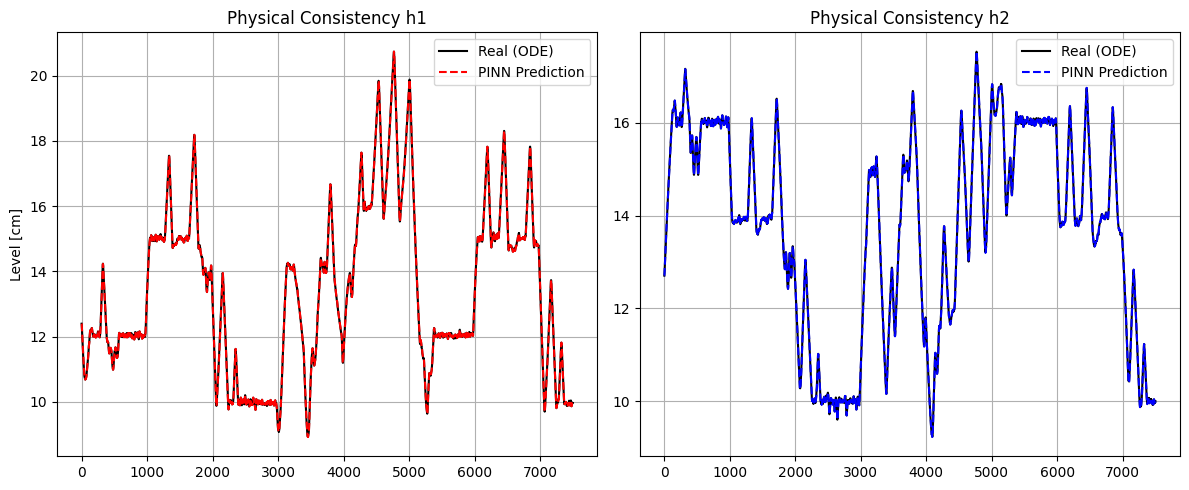

In [92]:
# --- NEURAL MODEL FIDELITY VALIDATION PLOTS ---
plt.figure(figsize=(12, 5))

# Trajectory comparison for Tank 1
plt.subplot(1, 2, 1)
plt.plot(h_real_seg[:, 0], 'k', label='Real (ODE)')
plt.plot(h_pinn_val[:, 0], 'r--', label='PINN Prediction')
plt.title('Physical Consistency h1')
plt.ylabel('Level [cm]')
plt.legend()
plt.grid(True)

# Trajectory comparison for Tank 2
plt.subplot(1, 2, 2)
plt.plot(h_real_seg[:, 1], 'k', label='Real (ODE)')
plt.plot(h_pinn_val[:, 1], 'b--', label='PINN Prediction')
plt.title('Physical Consistency h2')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Mean Error h3 (PINN): 0.0130 cm
Mean Error h4 (PINN): 0.0075 cm


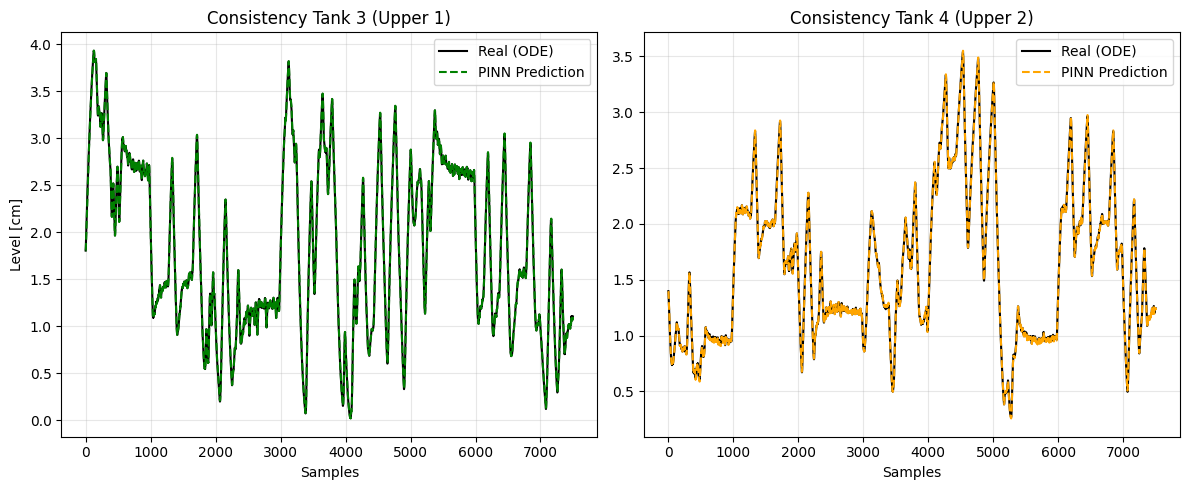

In [93]:
# --- CONSISTENCY CHECK: UPPER TANKS (h3 and h4) ---

# Quantitative evaluation of modeling error for upper tanks (MAE)
mae_h3_pinn = np.mean(np.abs(h_real_seg[:, 2] - h_pinn_val[:, 2]))
mae_h4_pinn = np.mean(np.abs(h_real_seg[:, 3] - h_pinn_val[:, 3]))

print(f"Mean Error h3 (PINN): {mae_h3_pinn:.4f} cm")
print(f"Mean Error h4 (PINN): {mae_h4_pinn:.4f} cm")

# Validation plots for upper levels
plt.figure(figsize=(12, 5))

# Trajectory comparison for Tank 3
plt.subplot(1, 2, 1)
plt.plot(h_real_seg[:, 2], 'k', label='Real (ODE)')
plt.plot(h_pinn_val[:, 2], 'g--', label='PINN Prediction')
plt.title('Consistency Tank 3 (Upper 1)')
plt.ylabel('Level [cm]')
plt.xlabel('Samples')
plt.legend()
plt.grid(True, alpha=0.3)

# Trajectory comparison for Tank 4
plt.subplot(1, 2, 2)
plt.plot(h_real_seg[:, 3], 'k', label='Real (ODE)')
plt.plot(h_pinn_val[:, 3], 'orange', linestyle='--', label='PINN Prediction')
plt.title('Consistency Tank 4 (Upper 2)')
plt.xlabel('Samples')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [94]:
# --- FIDELITY VALIDATION: PINN-NMPC VS REAL PLANT ---

# Interpolation of calculated voltages for continuous integration
u_pinn_fun = interp1d(t_test, u_history, axis=0, kind='linear', fill_value='extrapolate')

# Wrapper of the real nonlinear model fed by the PINN control sequence
ode_pinn_validation_wrapper = lambda tt, hh: nonlinear_ode_system_model(
    tt, hh, u_pinn_fun,
    A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2
)

# Simulation of the real physical plant under the optimal control sequence
sol_pinn_validation = solve_ivp(
    fun=ode_pinn_validation_wrapper,
    t_span=[t_test[0], t_test[-1]],
    y0=h0,
    method='RK45',
    t_eval=t_test,
    rtol=1e-7,
    atol=1e-9
)
h_real_validation = sol_pinn_validation.y.T

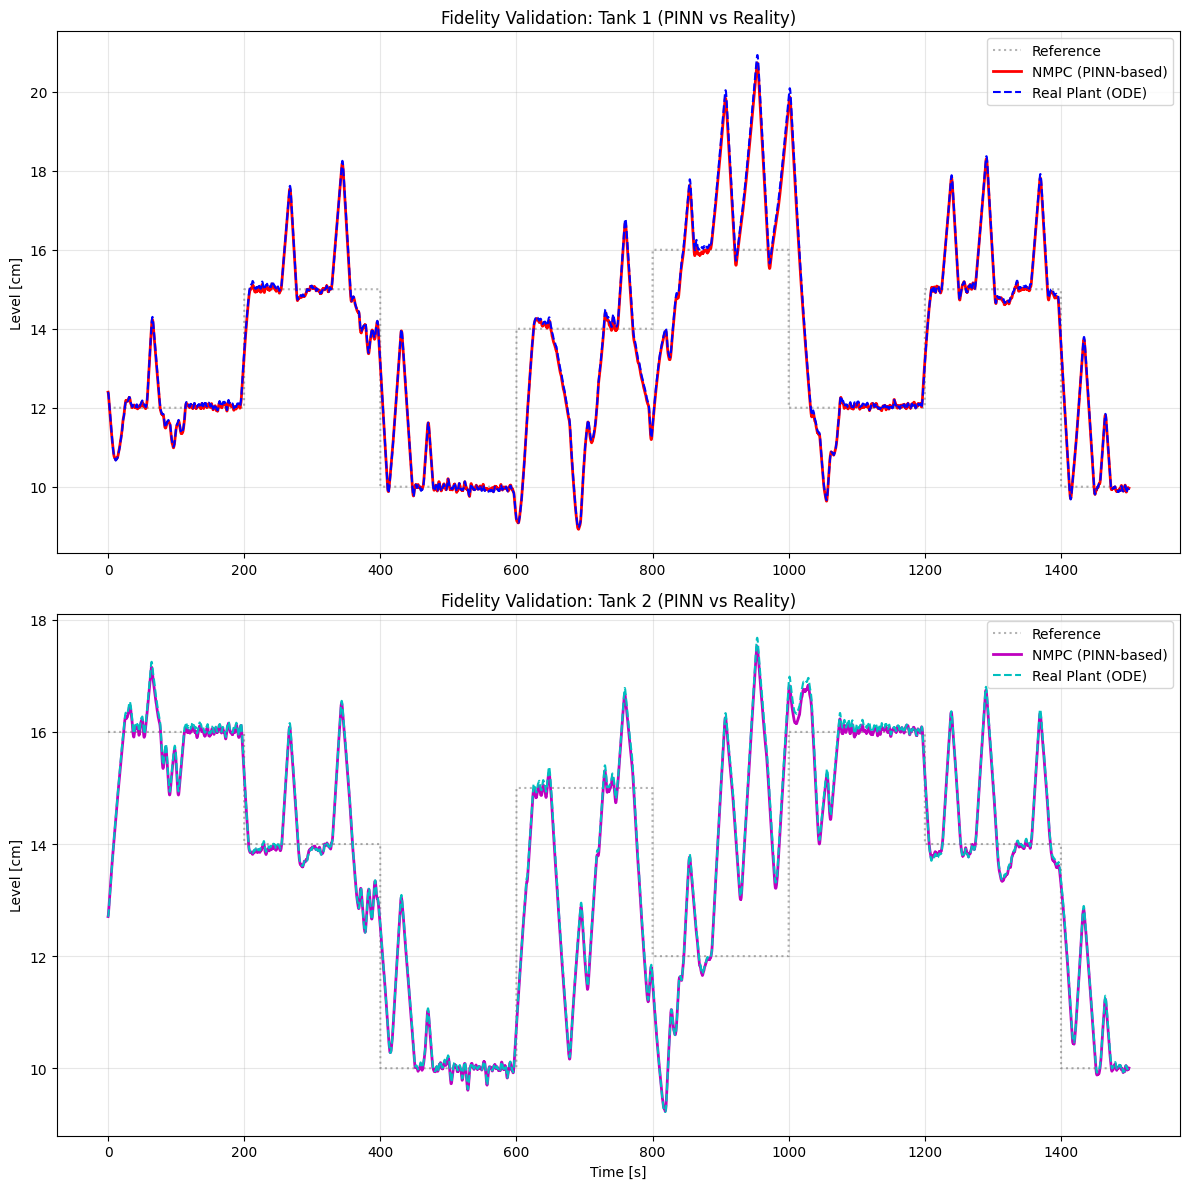

Average discrepancy PINN vs Real in h1: 0.05034 cm
Average discrepancy PINN vs Real in h2: 0.05003 cm


In [95]:
# --- MODEL-PLANT DISCREPANCY VISUALIZATION ---
plt.figure(figsize=(12, 12))

# Fidelity comparison for Tank 1 (Lower)
plt.subplot(2, 1, 1)
plt.plot(t_test, h_ref_full[:, 0], 'k:', alpha=0.3, label='Reference')
plt.plot(t_test, h_history[:, 0], 'r', linewidth=2, label='NMPC (PINN-based)')
plt.plot(t_test, h_real_validation[:, 0], 'b--', linewidth=1.5, label='Real Plant (ODE)')
plt.title('Fidelity Validation: Tank 1 (PINN vs Reality)')
plt.ylabel('Level [cm]')
plt.legend()
plt.grid(True, alpha=0.3)

# Fidelity comparison for Tank 2 (Lower)
plt.subplot(2, 1, 2)
plt.plot(t_test, h_ref_full[:, 1], 'k:', alpha=0.3, label='Reference')
plt.plot(t_test, h_history[:, 1], 'm', linewidth=2, label='NMPC (PINN-based)')
plt.plot(t_test, h_real_validation[:, 1], 'c--', linewidth=1.5, label='Real Plant (ODE)')
plt.title('Fidelity Validation: Tank 2 (PINN vs Reality)')
plt.ylabel('Level [cm]')
plt.xlabel('Time [s]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantification of discrepancy (Closed-loop modeling error)
discrepancy_h1 = np.mean(np.abs(h_history[:, 0] - h_real_validation[:, 0]))
discrepancy_h2 = np.mean(np.abs(h_history[:, 1] - h_real_validation[:, 1]))

print(f"Average discrepancy PINN vs Real in h1: {discrepancy_h1:.5f} cm")
print(f"Average discrepancy PINN vs Real in h2: {discrepancy_h2:.5f} cm")

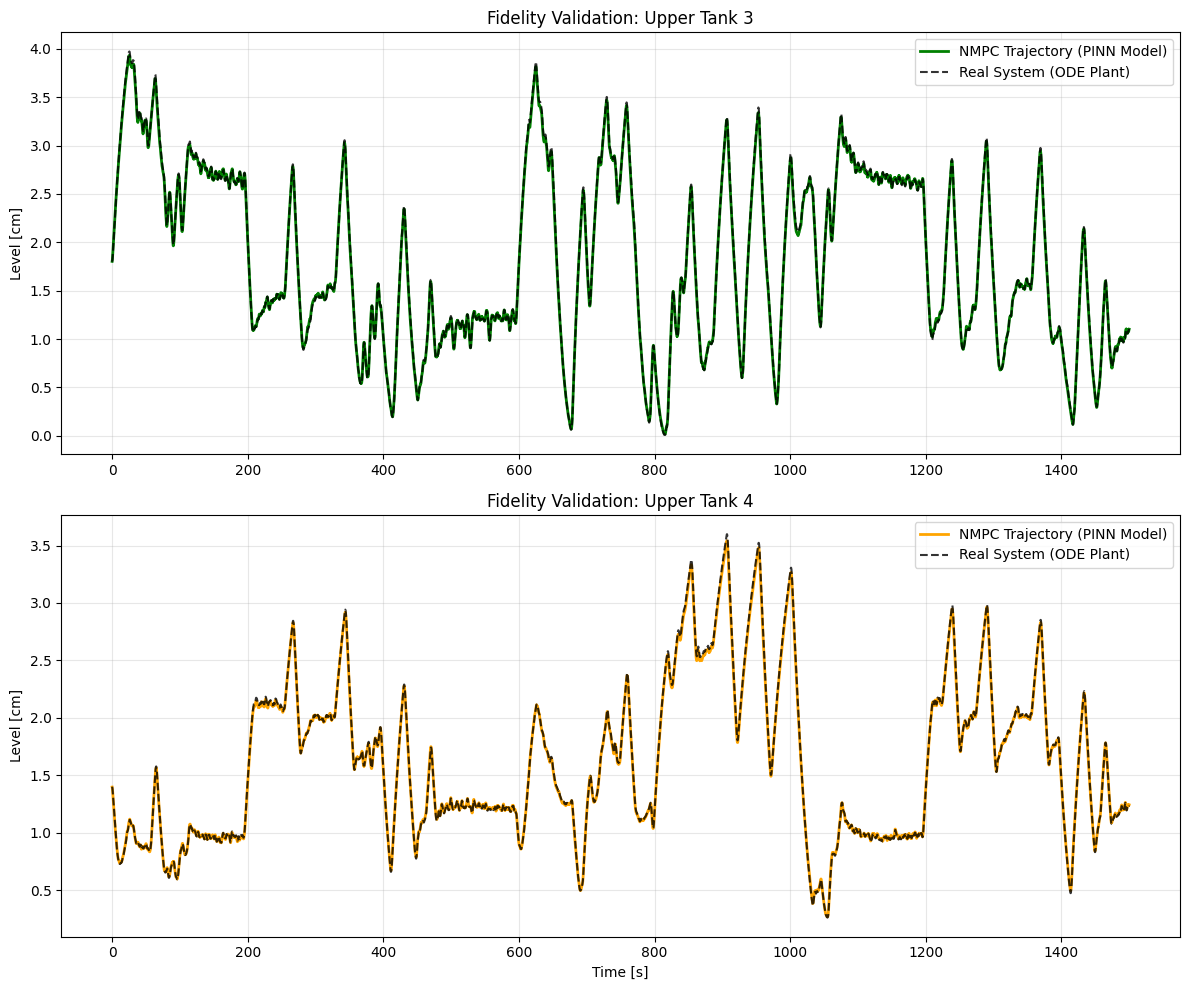

Average discrepancy PINN vs Real in h3: 0.01598 cm
Average discrepancy PINN vs Real in h4: 0.01138 cm


In [96]:
# --- FIDELITY VALIDATION: UPPER TANKS (h3 and h4) ---

plt.figure(figsize=(12, 10))

# Fidelity analysis for Tank 3 (Upper 1)
plt.subplot(2, 1, 1)
# Trajectory recorded by NMPC based on PINN prediction
plt.plot(t_test, h_history[:, 2], 'g', linewidth=2, label='NMPC Trajectory (PINN Model)')
# Real plant trajectory (ODE) under the same control profile
plt.plot(t_test, h_real_validation[:, 2], 'k--', linewidth=1.5, alpha=0.8, label='Real System (ODE Plant)')
plt.title('Fidelity Validation: Upper Tank 3')
plt.ylabel('Level [cm]')
plt.legend()
plt.grid(True, alpha=0.3)

# Fidelity analysis for Tank 4 (Upper 2)
plt.subplot(2, 1, 2)
plt.plot(t_test, h_history[:, 3], 'orange', linewidth=2, label='NMPC Trajectory (PINN Model)')
plt.plot(t_test, h_real_validation[:, 3], 'k--', linewidth=1.5, alpha=0.8, label='Real System (ODE Plant)')
plt.title('Fidelity Validation: Upper Tank 4')
plt.ylabel('Level [cm]')
plt.xlabel('Time [s]')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Discrepancy calculation (Closed-loop prediction error for upper states)
discrepancy_h3 = np.mean(np.abs(h_history[:, 2] - h_real_validation[:, 2]))
discrepancy_h4 = np.mean(np.abs(h_history[:, 3] - h_real_validation[:, 3]))

print(f"Average discrepancy PINN vs Real in h3: {discrepancy_h3:.5f} cm")
print(f"Average discrepancy PINN vs Real in h4: {discrepancy_h4:.5f} cm")